In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\breast-cancer.csv')

In [3]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
329,895633,M,16.26,21.88,107.50,826.8,0.11650,0.12830,0.179900,0.07981,...,17.73,25.21,113.70,975.2,0.1426,0.21160,0.33440,0.10470,0.2736,0.07953
73,859983,M,13.80,15.79,90.43,584.1,0.10070,0.12800,0.077890,0.05069,...,16.57,20.86,110.30,812.4,0.1411,0.35420,0.27790,0.13830,0.2589,0.10300
30,853401,M,18.63,25.11,124.80,1088.0,0.10640,0.18870,0.231900,0.12440,...,23.15,34.01,160.50,1670.0,0.1491,0.42570,0.61330,0.18480,0.3444,0.09782
69,859487,B,12.78,16.49,81.37,502.5,0.09831,0.05234,0.036530,0.02864,...,13.46,19.76,85.67,554.9,0.1296,0.07061,0.10390,0.05882,0.2383,0.06410
419,906290,B,11.16,21.41,70.95,380.3,0.10180,0.05978,0.008955,0.01076,...,12.36,28.92,79.26,458.0,0.1282,0.11080,0.03582,0.04306,0.2976,0.07123


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.duplicated().sum()

0

#### **No duplicates or null values detected**

## **Univariate Analysis**

### **diagnosis**

<Axes: xlabel='diagnosis', ylabel='count'>

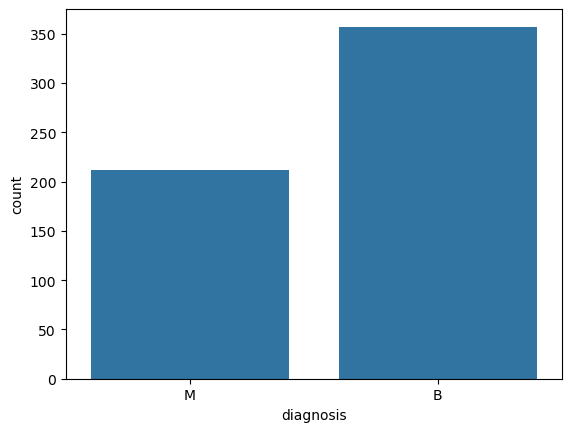

In [9]:
sns.countplot(x='diagnosis',data=df)

In [10]:
df['diagnosis'].value_counts(normalize=True)*100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

#### The dataset shows mild class imbalance (~63:37), which is not severe enough to require aggressive resampling, but evaluation should prioritize recall for the malignant class due to its higher real-world cost

### **radius_mean**

<Axes: xlabel='radius_mean', ylabel='Count'>

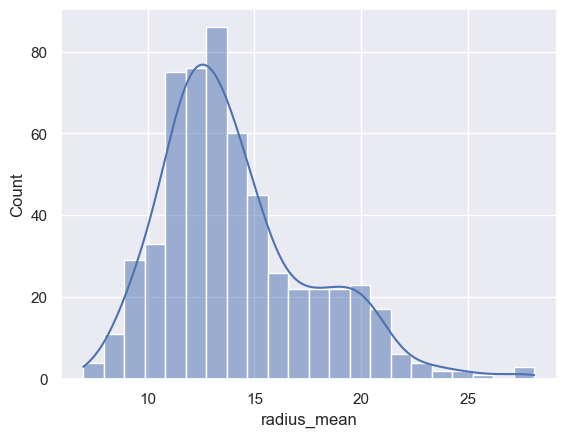

In [13]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.histplot(x='radius_mean',data=df,kde=True)

In [14]:
df['radius_mean'].describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: radius_mean, dtype: float64

In [15]:
df['radius_mean'].skew()

0.9423795716730992

While the majority of the data (50%) is tightly clustered within the Interquartile Range (IQR) of 11.70 to 15.78, the significant gap between the 75th percentile and the maximum value indicates the presence of potential outliers or a specific subset of more advanced clinical cases. From a modeling perspective, this positive skewness and the range of values suggest that applying a log transformation or StandardScaler could be beneficial to normalize the feature distribution and improve the performance of distance-based or linear algorithms.

### **texture_mean**

<Axes: xlabel='texture_mean', ylabel='Count'>

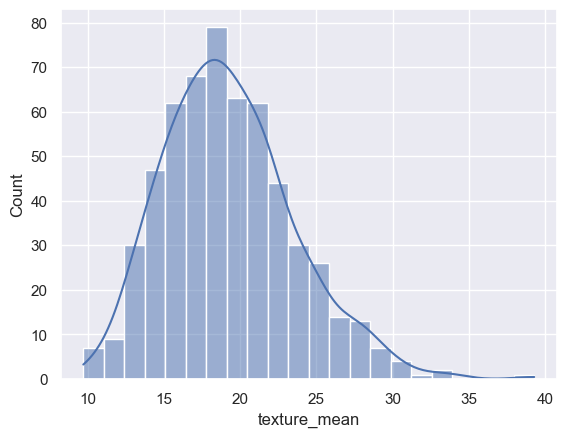

In [18]:
sns.histplot(x='texture_mean',data=df,kde=True)

In [19]:
df['texture_mean'].describe()

count    569.000000
mean      19.289649
std        4.301036
min        9.710000
25%       16.170000
50%       18.840000
75%       21.800000
max       39.280000
Name: texture_mean, dtype: float64

The data is slightly right-skewed, evidenced by the mean (19.29) being higher than the median (18.84). The interquartile range (IQR), which contains the middle 50% of the data, spans from 16.17 to 21.80. The significant jump from the 75th percentile to the maximum value (39.28) strongly suggests the presence of outliers at the upper end of the distribution.

Modeling Considerations:
The slight skewness and the presence of extreme outliers (the maximum is nearly twice the 75th percentile) may violate assumptions of normality required by some algorithms, such as Linear Regression. To ensure robust model performance, especially with distance-based or linear models, the following steps are recommended during preprocessing:

Normalization/Standardization: Apply a StandardScaler to remove the mean and scale to unit variance.

Outlier Management: Visually inspect the upper tail using a boxplot or histogram. Strategies might involve capping outliers or using robust algorithms (e.g., Tree-based methods) that are less sensitive to extreme values.

### **perimeter_mean**

<Axes: xlabel='perimeter_mean', ylabel='Count'>

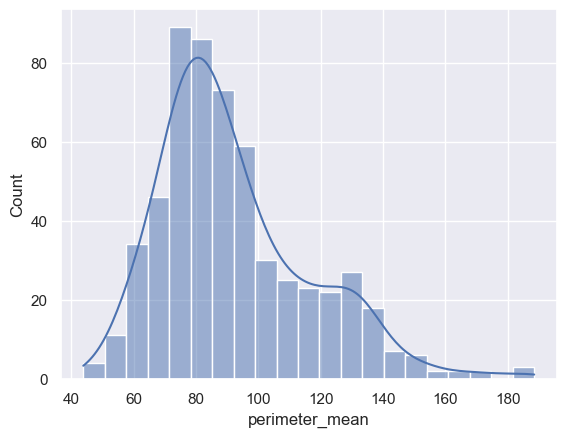

In [22]:
sns.histplot(x='perimeter_mean',kde=True,data=df)

In [23]:
df['perimeter_mean'].describe()

count    569.000000
mean      91.969033
std       24.298981
min       43.790000
25%       75.170000
50%       86.240000
75%      104.100000
max      188.500000
Name: perimeter_mean, dtype: float64

The dataset exhibits significant variability, with a standard deviation of 24.30. The values span from a minimum of 43.79 to a maximum of 188.50, indicating a wide range in tumor perimeters.

Distribution Shape:
The data shows a strong positive (right) skew, indicated by the mean being substantially larger than the median. While the middle 50% of the observations (IQR) fall between 75.17 and 104.10, the very large maximum value (188.50) confirms a long tail extending toward the higher values.

Modeling Insights
The pronounced right skewness and the presence of extreme outliers at the upper end are important for preprocessing:

Skewness Handling: Given the skewness, models that assume normally distributed data (like Linear Regression) will benefit from a log transformation of this feature.

Outlier Robustness: The significant gap between the 75th percentile and the maximum suggests outliers. Using robust scaling methods or modeling techniques less sensitive to outliers (like Tree-based methods) would be advantageous.

In [25]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **area_mean**

<Axes: xlabel='area_mean', ylabel='Count'>

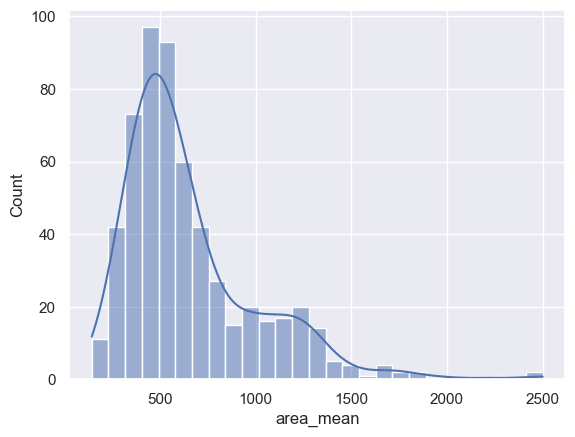

In [27]:
sns.histplot(x='area_mean',data=df,kde=True)

In [28]:
df['area_mean'].describe()

count     569.000000
mean      654.889104
std       351.914129
min       143.500000
25%       420.300000
50%       551.100000
75%       782.700000
max      2501.000000
Name: area_mean, dtype: float64

The data shows a very strong positive (right) skew, indicated by the mean being substantially larger than the median. While the middle 50% of the observations (IQR) fall between 420.30 and 782.70, the maximum value (2501.00) is more than three times the 75th percentile, confirming a very long tail extending toward the higher values.

Modeling Insights
The pronounced right skewness, significant spread, and extreme outliers are critical factors for preprocessing:

Extreme Skewness Handling: Given the massive skewness and wide range, applying a logarithmic transformation to this feature is highly recommended. A log transformation will compress the tail and make the distribution much more symmetric, which is often essential for algorithm performance.

Outlier Impact: The extreme outliers (e.g., the maximum of 2501) can severely distort many models. Visualizing these using a boxplot is crucial to decide if they are erroneous data or important clinical exceptions. Distance-based or linear models will be very sensitive to these points unless they are addressed.

Scaling and Normalization: Following skewness reduction, normalization (like Min-Max Scaling) or standardization (StandardScaler) will be necessary, as the scale of area_mean is orders of magnitude larger than features like texture_mean and perimeter_mean, which could dominate the model fitting

### **smoothness_mean**

<Axes: xlabel='smoothness_mean', ylabel='Count'>

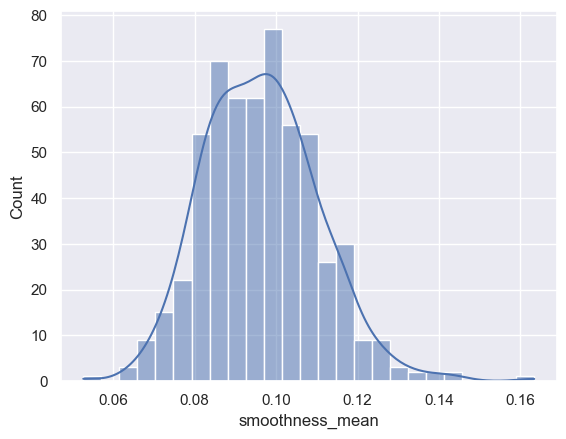

In [31]:
sns.histplot(x='smoothness_mean',data=df,kde=True)

In [32]:
df['smoothness_mean'].describe()

count    569.000000
mean       0.096360
std        0.014064
min        0.052630
25%        0.086370
50%        0.095870
75%        0.105300
max        0.163400
Name: smoothness_mean, dtype: float64

The dataset exhibits very low variability, with a small standard deviation of 0.014. The values span from a minimum of 0.053 to a maximum of 0.163, indicating a tight cluster of tumor smoothness values.

Distribution Shape:
The data appears to follow a nearly normal distribution. The mean and median are extremely close, and the IQR (Interquartile Range) from 0.086 to 0.105 suggests a symmetrical concentration of the middle 50% of the data. The distribution is relatively balanced around its center.

Modeling Insights
The near-normal distribution and low variance of this feature make it well-suited for machine learning models:

Modeling Assumptions: This feature aligns well with the assumptions of normality required by models like Linear Regression and Discriminant Analysis without the need for transformations (like log-scaling).

Preprocessing: Standard scaling (StandardScaler) or normalization is still recommended, but primarily to bring this feature onto the same scale as others (like the much larger area_mean), ensuring that its contribution is balanced during model fitting. It is robust and unlikely to require outlier removal.

### **compactness_mean**

<Axes: xlabel='compactness_mean', ylabel='Count'>

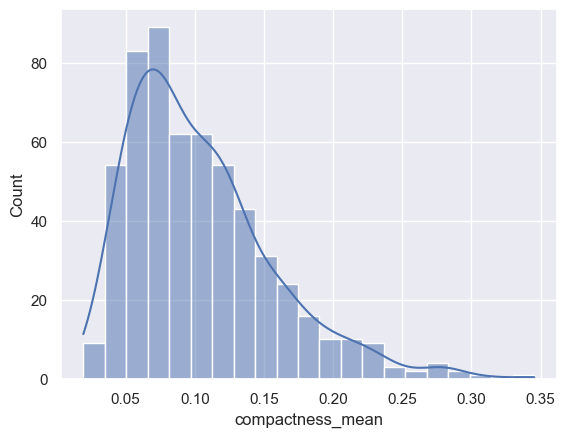

In [35]:
sns.histplot(x='compactness_mean',kde=True,data=df)

In [36]:
df['compactness_mean'].describe()

count    569.000000
mean       0.104341
std        0.052813
min        0.019380
25%        0.064920
50%        0.092630
75%        0.130400
max        0.345400
Name: compactness_mean, dtype: float64

The data shows a noticeable right (positive) skew. The mean is greater than the median, and while the central 50% of the data (IQR) is clustered between 0.065 and 0.130, there is a long tail extending toward the maximum value of 0.345. This indicates that although most tumors have low-to-moderate compactness, there is a distinct subgroup with significantly higher compactness values.

Modeling Insights
The right skewness and the range of this feature are important for preprocessing:

Skewness Correction: To make this feature more symmetric and improve the performance of models sensitive to skewness (like Logistic Regression), applying a transformation, such as a log transformation, is recommended.

Outlier Check: The high maximum value suggests potential outliers in the upper tail. Visualizing this distribution with a boxplot would be beneficial to determine how to best handle these extreme values before modeling

### **concavity_mean**

<Axes: xlabel='concavity_mean', ylabel='Count'>

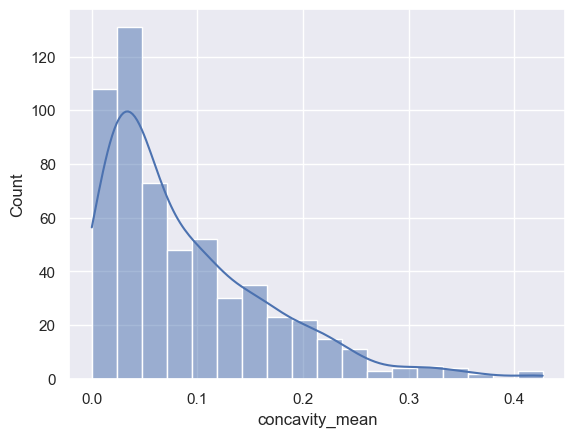

In [39]:
sns.histplot(x='concavity_mean',data=df,kde=True)

In [40]:
df['concavity_mean'].describe()

count    569.000000
mean       0.088799
std        0.079720
min        0.000000
25%        0.029560
50%        0.061540
75%        0.130700
max        0.426800
Name: concavity_mean, dtype: float64

The dataset exhibits high variability relative to its mean, with a standard deviation of 0.080. The values span from a minimum of 0.000 (indicating no concave portions in some tumors) to a maximum of 0.427, showing a wide range of concavity levels.Distribution Shape:The data shows a very strong positive (right) skew. The mean is much larger than the median, and while the central 50% of the data (IQR) is bounded between 0.030 and 0.131, there is an extremely long tail extending toward the maximum value. This indicates a high concentration of tumors with low concavity, but a critical subset has very severe concave contour features.Modeling InsightsThe extreme right skewness and the zero minimum value are crucial for preprocessing:Extreme Skewness Handling: Given the massive skewness, a transformation is highly recommended to normalize the distribution for linear or distance-based models. However, because the minimum value is exactly 0, a standard log transformation cannot be used directly. Instead, a transformation like $\log(1+x)$ (where $x$ is concavity_mean) or a Square Root transformation would be appropriate to handle the zeros while compressing the long tail.Clinical Relevance: The long tail suggests that high concavity values might be strong indicators for a specific classification (e.g., malignant). This feature should be carefully examined during exploratory data analysis (EDA) against the target variable.

### **concave points_mean**

<Axes: xlabel='concave points_mean', ylabel='Count'>

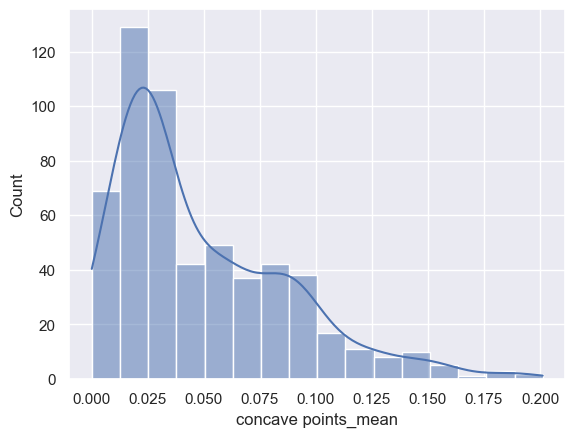

In [43]:
sns.histplot(x='concave points_mean',data=df,kde=True)

In [44]:
df['concave points_mean'].describe()

count    569.000000
mean       0.048919
std        0.038803
min        0.000000
25%        0.020310
50%        0.033500
75%        0.074000
max        0.201200
Name: concave points_mean, dtype: float64

Distribution Shape:
The data shows a strong positive (right) skew. The mean is substantially larger than the median, and while the central 50% of the data (IQR) falls between 0.020 and 0.074, there is a pronounced tail extending toward the maximum value. Similar to concavity_mean, this indicates a high concentration of tumors with few concave points, paired with a distinct subgroup exhibiting a much higher number of concave contour features.

### **symmetry_mean**

<Axes: xlabel='symmetry_mean', ylabel='Count'>

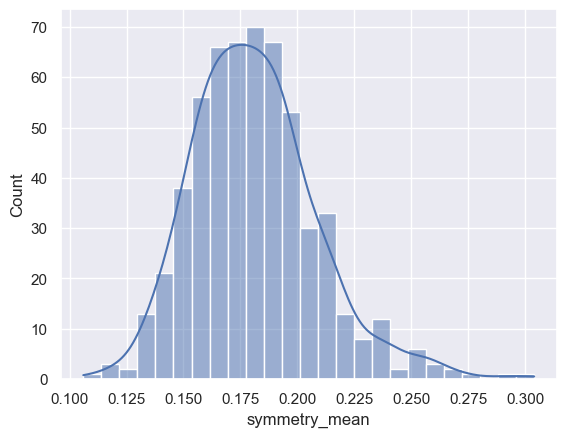

In [47]:
sns.histplot(x='symmetry_mean',data=df,kde=True)

In [48]:
df['symmetry_mean'].describe()

count    569.000000
mean       0.181162
std        0.027414
min        0.106000
25%        0.161900
50%        0.179200
75%        0.195700
max        0.304000
Name: symmetry_mean, dtype: float64

The dataset exhibits low variability, with a small standard deviation of 0.027. The values span from a minimum of 0.106 to a maximum of 0.304, indicating a relatively compact distribution of tumor symmetry values.

Distribution Shape:
The data appears to follow a nearly normal (Gaussian) distribution. The proximity of the mean and median, combined with the balanced interquartile range (IQR) from 0.162 to 0.196, suggests a symmetrical concentration of the middle 50% of the data. The distribution is stable and lacks extreme skewness.

In [50]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

<Axes: xlabel='fractal_dimension_mean', ylabel='Count'>

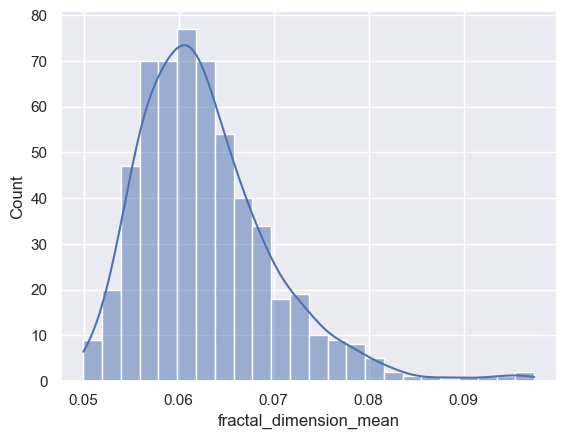

In [51]:
sns.histplot(x='fractal_dimension_mean',data=df,kde=True)

In [52]:
df['fractal_dimension_mean'].describe()

count    569.000000
mean       0.062798
std        0.007060
min        0.049960
25%        0.057700
50%        0.061540
75%        0.066120
max        0.097440
Name: fractal_dimension_mean, dtype: float64

The dataset exhibits very low variability, with a very small standard deviation of 0.0071. The values span a narrow range from a minimum of 0.0500 to a maximum of 0.0974, indicating that tumor fractal dimensions are tightly clustered.

Distribution Shape:
The data appears to follow a nearly normal (Gaussian) distribution. The proximity of the mean and median, combined with the relatively balanced interquartile range (IQR) from 0.0577 to 0.0661, suggests a symmetrical concentration of the middle 50% of the observations. The distribution lacks pronounced skewness.

In [85]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **radius_se**

<Axes: xlabel='radius_se', ylabel='Count'>

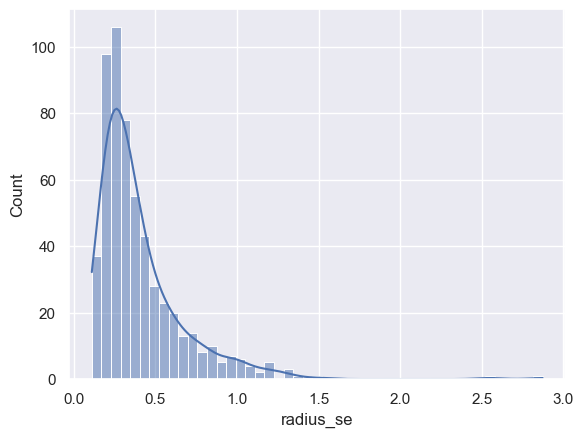

In [88]:
sns.histplot(x='radius_se',data=df,kde=True)

In [90]:
df['radius_se'].describe()

count    569.000000
mean       0.405172
std        0.277313
min        0.111500
25%        0.232400
50%        0.324200
75%        0.478900
max        2.873000
Name: radius_se, dtype: float64

In a clinical context, a higher radius_se suggests greater irregularity in the cell's shape. Since the top 25% of the data starts at 0.478 but stretches all the way to 2.873, these high-value observations likely warrant closer inspection as they deviate significantly from the "norm" established by the lower 75% of the data.

### **texture_se**

<Axes: xlabel='texture_se', ylabel='Count'>

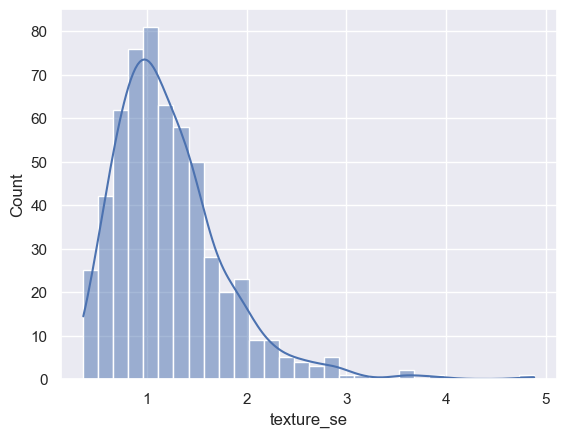

In [96]:
sns.histplot(x='texture_se',data=df,kde=True)

In [98]:
df['texture_se'].describe()

count    569.000000
mean       1.216853
std        0.551648
min        0.360200
25%        0.833900
50%        1.108000
75%        1.474000
max        4.885000
Name: texture_se, dtype: float64

A high texture_se indicates that the texture appearance across different parts of the cell nucleus was highly inconsistent. In machine learning models for pathology, high standard error values often serve as important features for distinguishing between benign and malignant cases, as malignant cells frequently exhibit more chaotic and less uniform physical characteristics.

### **perimeter_se**

<Axes: xlabel='perimeter_se', ylabel='Count'>

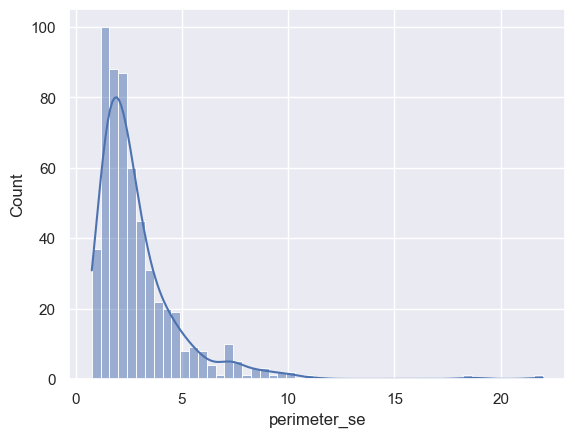

In [101]:
sns.histplot(x='perimeter_se',kde=True,data=df)

In [107]:
df['perimeter_se'].describe()

count    569.000000
mean       2.866059
std        2.021855
min        0.757000
25%        1.606000
50%        2.287000
75%        3.357000
max       21.980000
Name: perimeter_se, dtype: float64

In automated cell analysis, perimeter_se helps identify the "smoothness" or "predictability" of a cell's boundary. A high SE in perimeter often correlates with nucleic pleomorphism—a hallmark of malignancy where cells vary significantly in size and shape. Observations in the top 25% (above 3.357) likely represent the most morphologically complex cases in this dataset.

In [110]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **area_se**

<Axes: xlabel='area_se', ylabel='Count'>

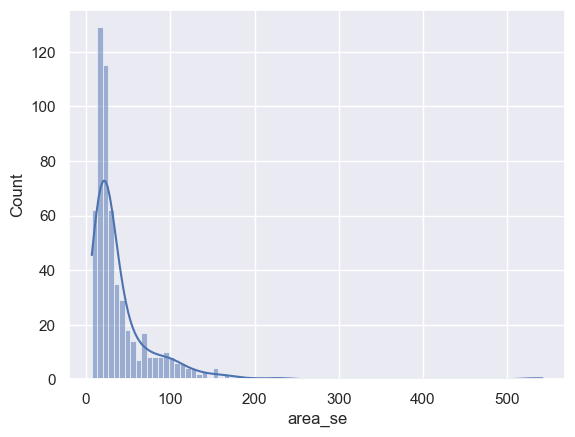

In [114]:
sns.histplot(x='area_se',data=df,kde=True)

In [116]:
df['area_se'].describe()

count    569.000000
mean      40.337079
std       45.491006
min        6.802000
25%       17.850000
50%       24.530000
75%       45.190000
max      542.200000
Name: area_se, dtype: float64

In many classification tasks involving this specific dataset, area_se is often one of the most influential features. A high area_se is a strong indicator of asymmetry and irregularity, which are primary morphological markers used to distinguish malignant tumors from benign ones. Samples scoring in that upper 25% (above 45.19) are likely the primary candidates for further pathological review.

### **smoothness_se**

<Axes: xlabel='smoothness_se', ylabel='Count'>

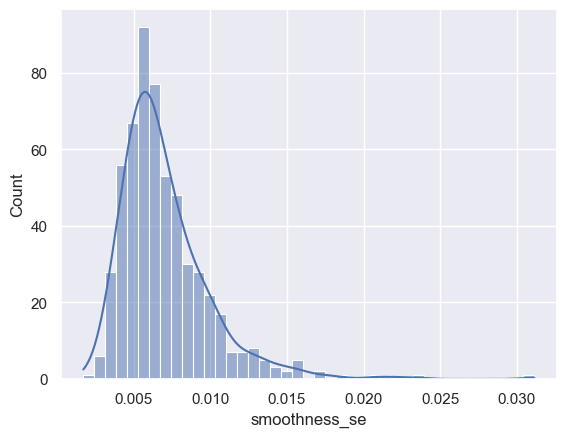

In [120]:
sns.histplot(x='smoothness_se',data=df,kde=True)

In [122]:
df['smoothness_se'].describe()

count    569.000000
mean       0.007041
std        0.003003
min        0.001713
25%        0.005169
50%        0.006380
75%        0.008146
max        0.031130
Name: smoothness_se, dtype: float64

smoothness_se evaluates the "consistency of the irregularity." While the smoothness feature itself looks at how much the radius changes, the Standard Error captures how much that variation fluctuates. In diagnostic modeling, a high smoothness_se can indicate a cell boundary that is not just rough, but inconsistently rough, which is often a key differentiator in high-dimensional feature sets used for classification.

### **compactness_se**

<Axes: xlabel='compactness_se', ylabel='Count'>

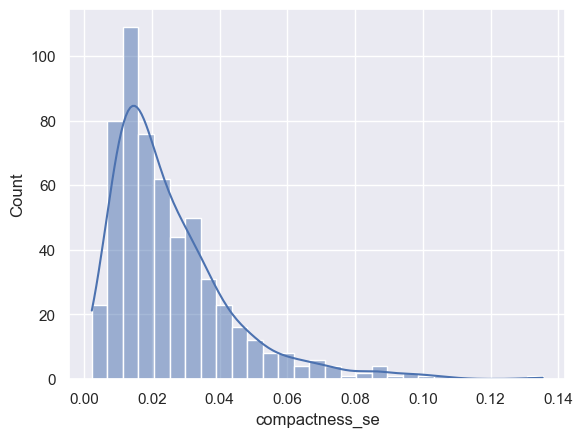

In [126]:
sns.histplot(x='compactness_se',data=df,kde=True)

In [128]:
df['compactness_se'].describe()

count    569.000000
mean       0.025478
std        0.017908
min        0.002252
25%        0.013080
50%        0.020450
75%        0.032450
max        0.135400
Name: compactness_se, dtype: float64

compactness_se is a secondary morphological feature. While "compactness" itself measures how closely the shape resembles a circle, its Standard Error highlights the volatility of that shape. High values in the upper quartile typically correlate with cells that have jagged or "frilly" edges, a common characteristic in the feature engineering stage of malignancy prediction models.

In [131]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **concavity_se**

<Axes: xlabel='concavity_se', ylabel='Count'>

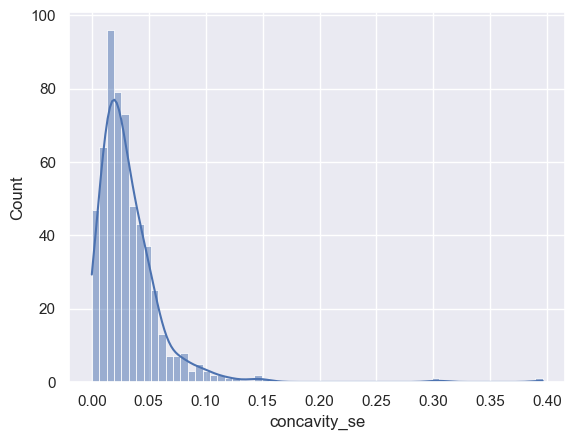

In [134]:
sns.histplot(x='concavity_se',data=df,kde=True)

In [136]:
df['concavity_se'].describe()

count    569.000000
mean       0.031894
std        0.030186
min        0.000000
25%        0.015090
50%        0.025890
75%        0.042050
max        0.396000
Name: concavity_se, dtype: float64

concavity_se is a critical feature for capturing the "complexity of the indentations." In a diagnostic context, malignancy is often associated with high concavity. However, a high Standard Error in concavity suggests that these indentations are not uniform around the cell, potentially indicating a highly asymmetrical and chaotic growth pattern. These high-value outliers are often high-priority features for classification algorithms.

### **concave points_se**

<Axes: xlabel='concave points_se', ylabel='Count'>

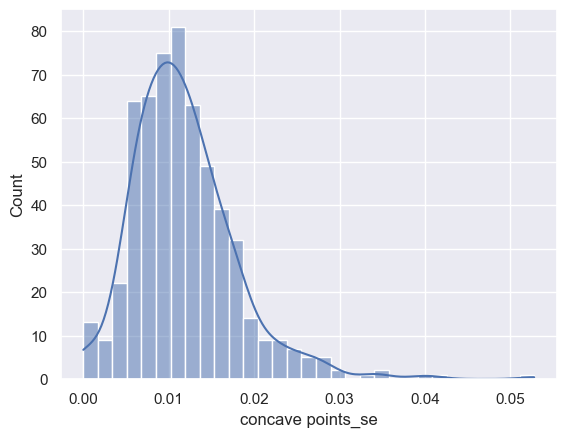

In [140]:
sns.histplot(x='concave points_se',data=df,kde=True)

In [142]:
df['concave points_se'].describe()

count    569.000000
mean       0.011796
std        0.006170
min        0.000000
25%        0.007638
50%        0.010930
75%        0.014710
max        0.052790
Name: concave points_se, dtype: float64

concave points_se is often a high-performing feature in machine learning classifiers for pathology. While the number of concave points is a direct indicator of shape irregularity, the Standard Error helps the model understand the "certainty" of that irregularity. A high SE here suggests that the indentations are unevenly distributed or poorly defined, which can be a key mathematical signature for identifying complex cell structures.

### **symmetry_se**

<Axes: xlabel='symmetry_se', ylabel='Count'>

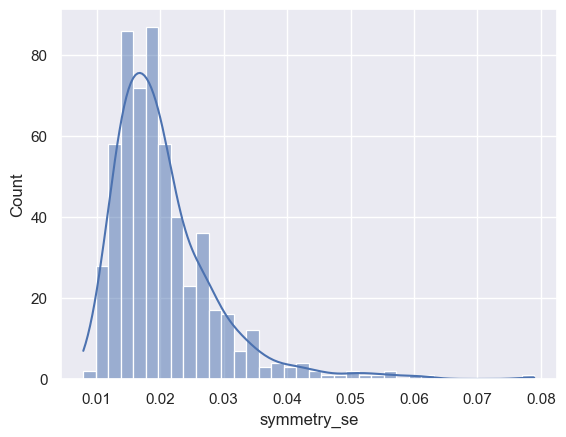

In [146]:
sns.histplot(x='symmetry_se',data=df,kde=True)

In [148]:
df['symmetry_se'].describe()

count    569.000000
mean       0.020542
std        0.008266
min        0.007882
25%        0.015160
50%        0.018730
75%        0.023480
max        0.078950
Name: symmetry_se, dtype: float64

symmetry_se is an important "noise" indicator. In biological terms, high symmetry is often associated with healthy, benign cells. A high Standard Error in symmetry suggests that the cell's balance is difficult to calculate consistently—perhaps because the nucleus is elongated, notched, or tilted in a way that makes its axis of symmetry ambiguous. In predictive modeling, this feature helps refine the shape profile of the nucleus by adding a layer of measurement confidence.

### **fractal_dimension_se**

<Axes: xlabel='fractal_dimension_se', ylabel='Count'>

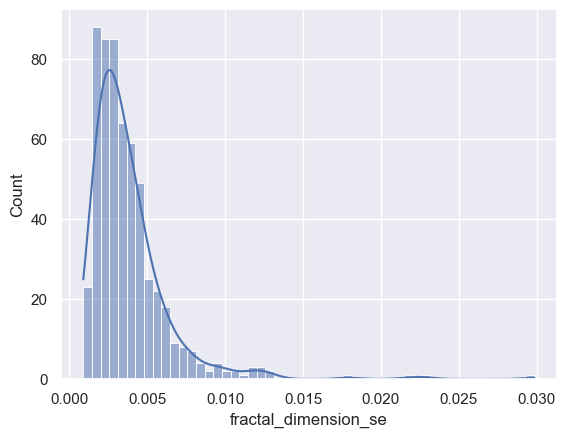

In [152]:
sns.histplot(x='fractal_dimension_se',data=df,kde=True)

In [154]:
df['fractal_dimension_se'].describe()

count    569.000000
mean       0.003795
std        0.002646
min        0.000895
25%        0.002248
50%        0.003187
75%        0.004558
max        0.029840
Name: fractal_dimension_se, dtype: float64

fractal_dimension_se is often considered a "fine-detail" feature. While the fractal dimension itself captures the overall jaggedness of the nucleus, its Standard Error reveals how much that jaggedness changes as you move along the boundary. In machine learning models for oncology, high values in this feature are frequently used to flag cells with "chaotic" perimeters, which are mathematically distinct from the more predictable boundaries of healthy cells.

In [157]:
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **radius_worst**

<Axes: xlabel='radius_worst', ylabel='Count'>

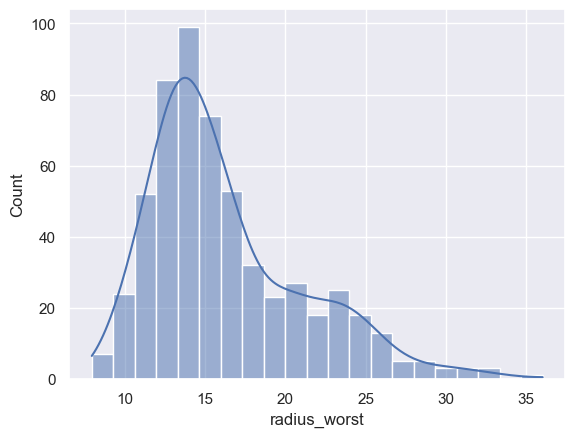

In [160]:
sns.histplot(x='radius_worst',data=df,kde=True)

In [162]:
df['radius_worst'].describe()

count    569.000000
mean      16.269190
std        4.833242
min        7.930000
25%       13.010000
50%       14.970000
75%       18.790000
max       36.040000
Name: radius_worst, dtype: float64

This variable represents the "Worst" (Mean of the three largest values) radius for cell nuclei in each sample. In diagnostic datasets, the "worst" or "largest" measurements often carry the most weight for classification, as they identify the most extreme physical characteristics present in a tumor.

The radius_worst feature is frequently one of the top predictors in machine learning models for breast cancer diagnosis. Because malignant tumors are often characterized by enlarged nuclei (macronucleoli), the "worst" radius measurement effectively captures the most aggressive physical indicators within a biopsy. Values in the upper quartile—especially those approaching the 36.04 maximum—are strong candidates for being flagged as malignant by predictive algorithms.

### **texture_worst**

<Axes: xlabel='texture_worst', ylabel='Count'>

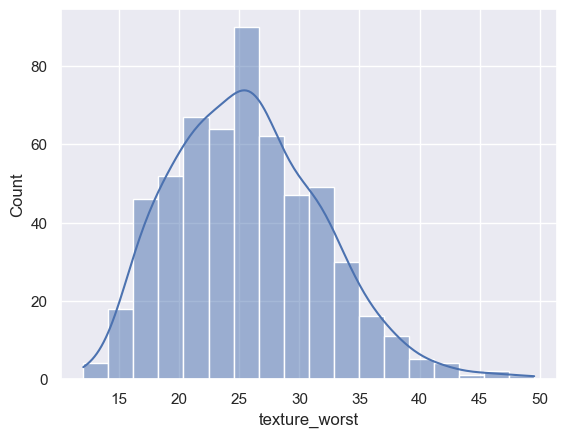

In [166]:
sns.histplot(x='texture_worst',data=df,kde=True)

In [168]:
df['texture_worst'].describe()

count    569.000000
mean      25.677223
std        6.146258
min       12.020000
25%       21.080000
50%       25.410000
75%       29.720000
max       49.540000
Name: texture_worst, dtype: float64

texture_worst is a powerful feature for identifying chromatin distribution and surface roughness. In a clinical setting, malignant cells often exhibit "clumped" or cleared chromatin, which manifests as high gray-scale variance (texture). Because this metric captures the "worst" cases in a biopsy, values in the upper quartile—specifically those exceeding 30.0—are often highly correlated with malignant classifications in automated screening tools.

### **perimeter_worst**

<Axes: xlabel='perimeter_worst', ylabel='Count'>

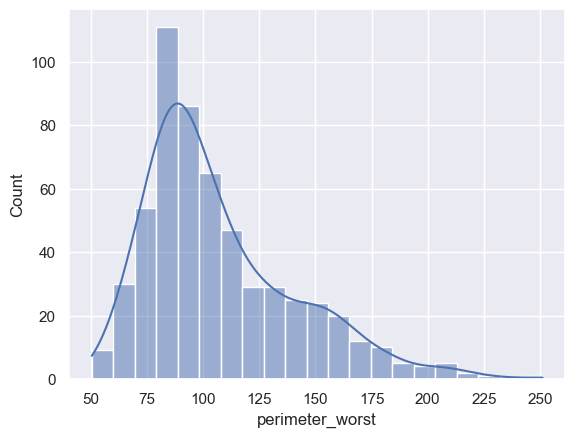

In [172]:
sns.histplot(x='perimeter_worst',data=df,kde=True)

In [174]:
df['perimeter_worst'].describe()

count    569.000000
mean     107.261213
std       33.602542
min       50.410000
25%       84.110000
50%       97.660000
75%      125.400000
max      251.200000
Name: perimeter_worst, dtype: float64

In many classification models, perimeter_worst is highly correlated with radius_worst and area_worst, but it specifically captures the complexity of the outer boundary. Because malignant cells often demonstrate a significant increase in nuclear size and perimeter (pleomorphism), this feature is frequently among the top-ranked predictors for identifying malignancy. Samples in the top 25% (above 125.4) typically represent the most physically aggressive morphological structures in the dataset.

### **area_worst**

<Axes: xlabel='area_worst', ylabel='Count'>

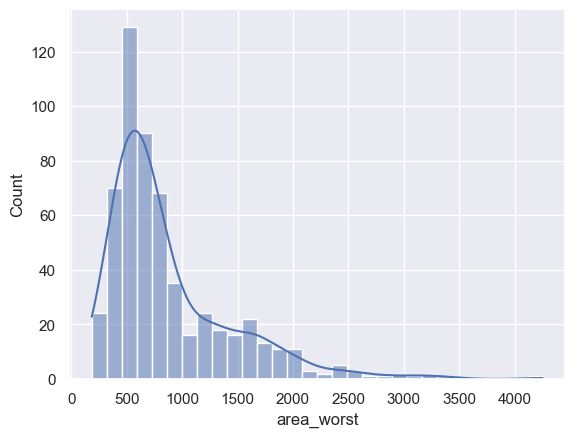

In [178]:
sns.histplot(x='area_worst',data=df,kde=True)

In [180]:
df['area_worst'].describe()

count     569.000000
mean      880.583128
std       569.356993
min       185.200000
25%       515.300000
50%       686.500000
75%      1084.000000
max      4254.000000
Name: area_worst, dtype: float64

In many predictive models, area_worst is the single most influential morphological predictor. Significant nuclear enlargement (increased area) is a primary hallmark of malignancy. The fact that the top 25% of the data spans from 1084.0 all the way to 4254.0 indicates that these high-value cases likely represent the most aggressive clinical presentations in the dataset. Any value significantly exceeding the 75th percentile is typically a high-priority flag for classification algorithms.

In [183]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **smoothness_worst**

<Axes: xlabel='smoothness_worst', ylabel='Count'>

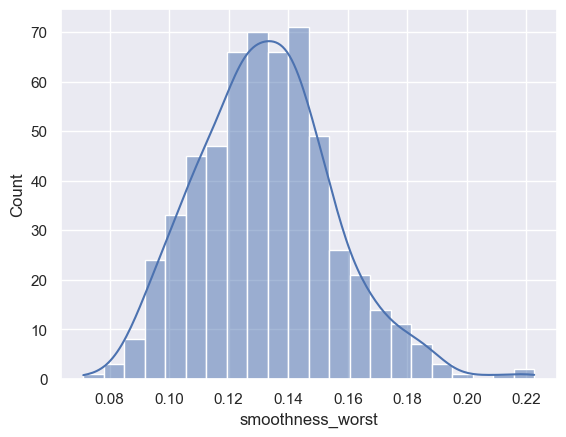

In [186]:
sns.histplot(x='smoothness_worst',data=df,kde=True
            )

In [188]:
df['smoothness_worst'].describe()

count    569.000000
mean       0.132369
std        0.022832
min        0.071170
25%        0.116600
50%        0.131300
75%        0.146000
max        0.222600
Name: smoothness_worst, dtype: float64

smoothness_worst is a refined metric for capturing membrane instability. While the "mean smoothness" looks at the cell overall, the "worst" smoothness focuses on the most jagged or irregular parts of the nucleus perimeter. In diagnostic classification, a shift toward the upper quartile (above 0.146) often signals a loss of structural integrity, a common morphological marker used by machine learning models to identify malignant cell populations.

### **compactness_worst**

<Axes: xlabel='compactness_worst', ylabel='Count'>

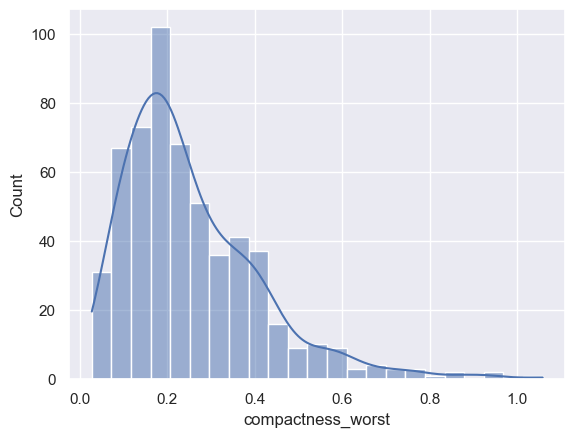

In [192]:
sns.histplot(data=df,x='compactness_worst',kde=True)

In [194]:
df['compactness_worst'].describe()

count    569.000000
mean       0.254265
std        0.157336
min        0.027290
25%        0.147200
50%        0.211900
75%        0.339100
max        1.058000
Name: compactness_worst, dtype: float64

compactness_worst is a vital feature for identifying pleomorphism—a condition where cell nuclei vary significantly in shape and size. In a clinical context, benign cells tend to be more "compact" (circular and smooth), while malignant cells often become elongated or jagged, leading to higher values in this metric. Observations in the upper quartile (above 0.339) are often primary indicators used by classification models to flag potentially malignant tissue.

### **concavity_worst**

<Axes: xlabel='concavity_worst', ylabel='Count'>

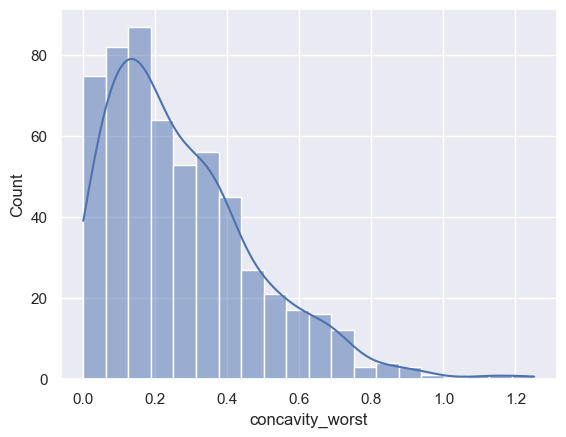

In [198]:
sns.histplot(x='concavity_worst',data=df,kde=True)

In [200]:
df['concavity_worst'].describe()

count    569.000000
mean       0.272188
std        0.208624
min        0.000000
25%        0.114500
50%        0.226700
75%        0.382900
max        1.252000
Name: concavity_worst, dtype: float64

concavity_worst is frequently cited as one of the most important features in breast cancer classification models. While "mean concavity" gives a general sense of the tissue, the "worst" concavity specifically hunts for the most deformed cells in the biopsy. High values (especially those in the top 25%) are strong indicators of nuclear pleomorphism, a primary hallmark used by pathologists and machine learning algorithms alike to identify malignant growth.

### **concave points_worst**

<Axes: xlabel='concave points_worst', ylabel='Count'>

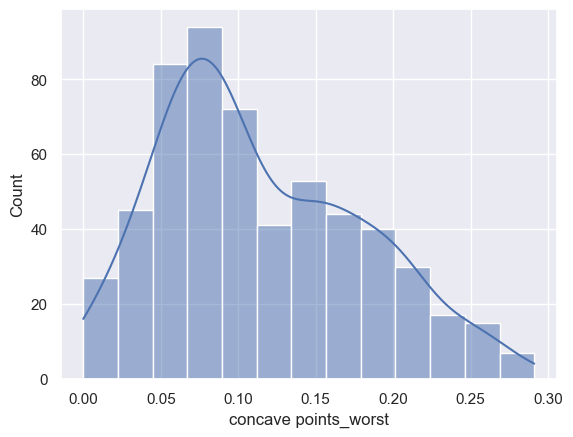

In [204]:
sns.histplot(x='concave points_worst',data=df,kde=True)

In [206]:
df['concave points_worst'].describe()

count    569.000000
mean       0.114606
std        0.065732
min        0.000000
25%        0.064930
50%        0.099930
75%        0.161400
max        0.291000
Name: concave points_worst, dtype: float64

The number of concave points is a direct measure of boundary irregularity. In clinical settings, as cells become malignant, their nuclei often lose their smooth, convex shape and develop numerous indentations. Because this feature captures the "worst" instances, values in the upper quartile (above 0.161) are frequently used as key indicators to differentiate between benign and malignant tissue.

### **symmetry_worst**

<Axes: xlabel='symmetry_worst', ylabel='Count'>

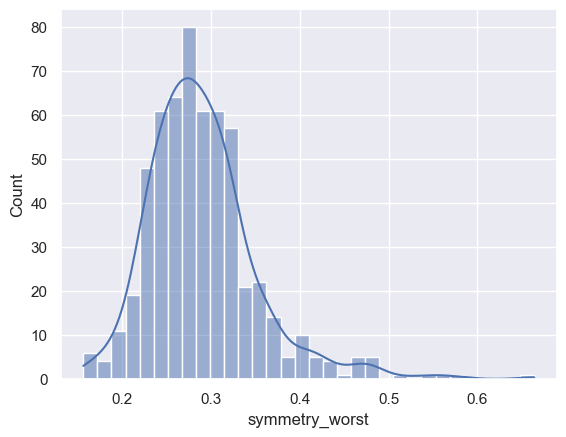

In [210]:
sns.histplot(x='symmetry_worst',data=df,kde=True)

In [212]:
df['symmetry_worst'].describe()

count    569.000000
mean       0.290076
std        0.061867
min        0.156500
25%        0.250400
50%        0.282200
75%        0.317900
max        0.663800
Name: symmetry_worst, dtype: float64

symmetry_worst is a refined metric for detecting structural instability. In biology, high symmetry usually points toward healthy, organized cell growth. As cells become malignant, they often lose this axial balance. Because this feature isolates the "worst" instances in a biopsy, it acts as a filter to find the most suspicious cells. Values in the top quartile (above 0.318) are frequently weighted heavily in classification models to separate benign samples from those showing early signs of morphological chaos.

### **fractal_dimension_worst**

<Axes: xlabel='fractal_dimension_worst', ylabel='Count'>

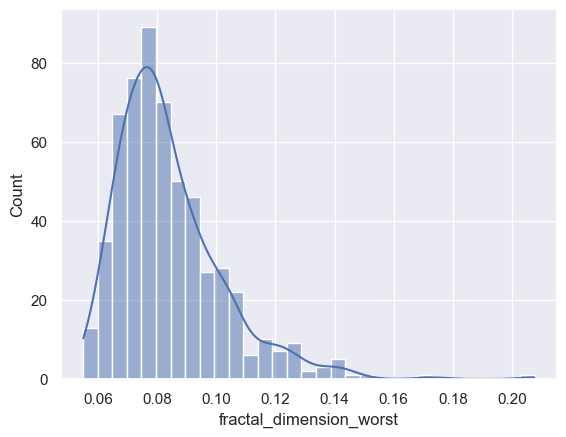

In [216]:
sns.histplot(x='fractal_dimension_worst',data=df,kde=True)

In [218]:
df['fractal_dimension_worst'].describe()

count    569.000000
mean       0.083946
std        0.018061
min        0.055040
25%        0.071460
50%        0.080040
75%        0.092080
max        0.207500
Name: fractal_dimension_worst, dtype: float64

fractal_dimension_worst is a powerful tool for capturing micro-scale boundary irregularity. While features like perimeter and area describe the size, the fractal dimension describes the quality of the boundary. In oncology, malignant cells often develop "hair-like" or highly irregular perimeters as they interact with their environment. In machine learning models, samples scoring in the top 25%—and particularly those approaching the 0.20+ range—are frequently flagged as showing the high morphological complexity associated with malignancy.

# 🧠 Breast Cancer Dataset — Univariate Analysis Summary
🎯 Target Variable Insight
The dataset exhibits a mild class imbalance (~63:37) between benign and malignant cases. While not severe enough to mandate aggressive resampling, this imbalance has important modeling implications:


Primary focus should be Recall for the malignant class, as false negatives carry high clinical risk.


Accuracy alone is insufficient — evaluation must include Recall, Precision, and F1-score.



## 📊 Feature-Level Univariate Insights

## 🔵 Size & Scale Features (radius, perimeter, area)
radius_mean, perimeter_mean, area_mean

These features show a consistent pattern:


Strong positive skewness


Presence of extreme upper-tail outliers


Large spread (especially area_mean)


Key Findings


Majority of tumors fall within a tight central band (IQR)


A small but critical subset exhibits very large values, likely representing advanced malignancies


area_mean is particularly extreme (max ≈ 3× Q3)


Modeling Insights


Log transformation is essential (especially for area_mean)


Standardization required due to scale dominance


Outliers may be:


clinically meaningful (retain cautiously)


or noise (requires validation via visualization)




## 👉 These features are high-signal predictors of malignancy.

## 🟡 Texture & Shape Complexity Features
texture_mean, compactness_mean, concavity_mean, concave_points_mean
5
Key Findings


Moderate to extreme right skewness


Long tails indicate rare but critical abnormal structures


Presence of zero values (concavity_mean)


Modeling Insights


Transformation required:


log(x + 1) or √x for zero-handling features




### Strong clinical signal:


High concavity / concave points → likely malignant




These features capture boundary irregularity, a key diagnostic trait


## 👉 These are structural complexity indicators — extremely valuable for classification.

### 🟢 Stable Morphological Features
smoothness_mean, symmetry_mean, fractal_dimension_mean
6
Key Findings


Near-normal distributions


Very low variance


Minimal skewness and outliers


Modeling Insights


No transformation required


Only scaling needed for consistency


Lower standalone predictive power but:


help stabilize models


improve linear separability




## 👉 These act as supporting features, not primary drivers.

## 🟣 Standard Error (SE) Features — Variability Signals
radius_se, texture_se, perimeter_se, area_se, etc.
Key Findings


Represent uncertainty / variability in measurements


High values indicate:


irregular growth


inconsistent morphology




Clinical Insight


Malignant cells tend to show:


higher variability


chaotic structural patterns




Modeling Insights


Often highly predictive


Especially:


area_se


perimeter_se




Capture second-order complexity (not size, but instability)


## 👉 These features are hidden differentiators between benign vs malignant.

## 🔴 “Worst” Features — Maximum Severity Indicators
radius_worst, area_worst, concavity_worst, etc.
6
Key Findings


Capture most extreme observations per sample


Strong separation in upper quartiles


Highly correlated with malignancy


Modeling Insights


Among the top predictors in most models


Represent:


maximum tumor aggression


worst-case morphology




#### 👉 These features often dominate model decision boundaries.

⚙️ Global Modeling Implications
🔧 Preprocessing Strategy
Based on univariate findings:


Log Transform Required


area_mean, perimeter_mean, concavity features




Scaling Mandatory


StandardScaler or RobustScaler




Outlier Strategy


Validate via visualization before removal


Prefer robust models if retaining





### 🧩 Feature Behavior Summary
Feature TypeBehaviorModeling RoleSize (area, radius, perimeter)Highly skewed, high variancePrimary predictorsShape complexity (concavity, compactness)Skewed, long tailMalignancy indicatorsStable features (smoothness, symmetry)Normal, low varianceSupporting featuresSE featuresVariability indicatorsHidden signal featuresWorst featuresExtreme valuesStrongest predictors

🚀 Final Insights & Takeaways


The dataset is feature-rich with strong biological meaning, not just statistical noise


Skewness is a dominant theme, requiring thoughtful preprocessing


Outliers are not necessarily bad — they may represent critical malignant cases


Clear separation signal exists in:


size features


concavity features


worst-case measurements




### 🔥 Most Important Insight:
This dataset is not limited by feature quality — it is limited by class overlap, meaning:


Feature engineering and transformation matter more than model complexity


Linear models (like Logistic Regression, LDA) can perform well if preprocessing is done correctly






## **BiVariate Analysis**

In [226]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs radius_mean**

In [229]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

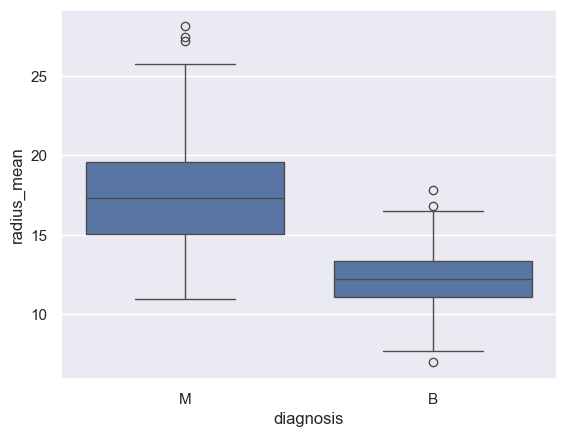

In [231]:
sns.boxplot(x='diagnosis',y='radius_mean',data=df)

In [233]:
df.groupby('diagnosis')['radius_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,6.981,17.85,1.780512,12.146524,12.200
M,10.950,28.11,3.203971,17.462830,17.325


The class-wise distribution of radius_mean reveals a strong and clinically meaningful separation between benign and malignant tumors. Malignant cases exhibit a significantly higher central tendency, with a mean of 17.46 compared to 12.15 for benign tumors, indicating that tumor size is a key differentiating factor in diagnosis.

In addition to this shift, malignant tumors show substantially higher variability (std = 3.20 vs 1.78), reflecting the heterogeneous and irregular growth patterns typically associated with malignancy. In contrast, benign tumors are more tightly clustered, suggesting consistent and controlled growth.

However, despite this strong separation, there exists a notable overlap region (≈ 11 to 18) where both benign and malignant cases coexist. This overlap represents the primary classification challenge, as tumors within this range cannot be reliably distinguished using radius alone.

From a modeling perspective, radius_mean serves as a high-signal feature and will contribute significantly to predictive performance. However, due to the overlap in mid-range values, it must be complemented with additional morphological features (such as concavity, compactness, and worst-case measurements) to improve classification accuracy.

🔥 Key Insight:

The dataset demonstrates clear separability at extremes but ambiguity in intermediate ranges, indicating that the limitation is not lack of signal, but class overlap—a critical factor that will influence model performance and decision boundaries

### **diagnosis vs texture_mean**

<Axes: xlabel='diagnosis', ylabel='texture_mean'>

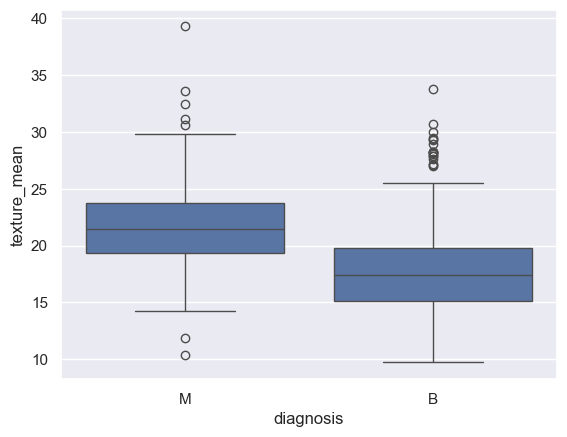

In [237]:
sns.boxplot(x='diagnosis',y='texture_mean',data=df)

In [239]:
df.groupby('diagnosis')['texture_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,9.71,33.81,3.995125,17.914762,17.39
M,10.38,39.28,3.779470,21.604906,21.46


The texture_mean feature shows a moderate upward shift for malignant tumors (mean ≈ 21.60) compared to benign cases (mean ≈ 17.91), indicating that malignant cells tend to have more irregular texture patterns.

However, unlike size-based features, the standard deviations are similar (~3.8–4.0), and there is a significant overlap in range, reducing its standalone discriminative power.

🔑 Insight:

texture_mean provides supporting signal rather than strong separation, making it useful when combined with other features, but insufficient on its own for accurate classification

### **diagnosis vs perimeter_mean**

<Axes: xlabel='diagnosis', ylabel='perimeter_mean'>

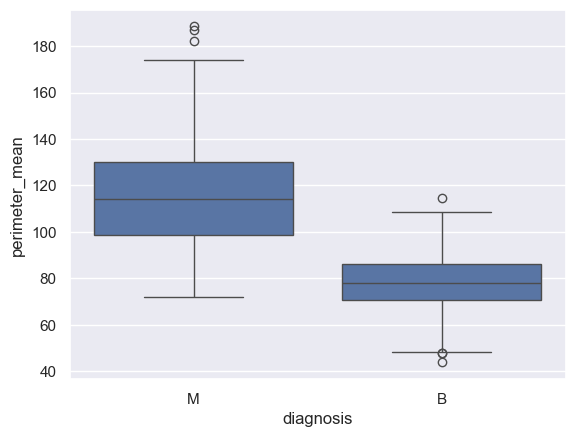

In [243]:
sns.boxplot(x='diagnosis',y='perimeter_mean',data=df)

In [245]:
df.groupby('diagnosis')['perimeter_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,43.79,114.6,11.807438,78.075406,78.18
M,71.90,188.5,21.854653,115.365377,114.20


The perimeter_mean feature shows a strong upward shift for malignant tumors (mean ≈ 115.37) compared to benign cases (mean ≈ 78.08), reinforcing that malignant tumors tend to have larger and more irregular boundaries.

Malignant cases also exhibit much higher variability (std ≈ 21.85 vs 11.81), indicating heterogeneous growth patterns. While there is some overlap in the mid-range, separation at the extremes is quite clear.

🔑 Insight:

perimeter_mean is a high-signal feature for classification, though it remains partially redundant with radius and area due to strong correlation

### **diagnosis vs area_mean**

<Axes: xlabel='diagnosis', ylabel='area_mean'>

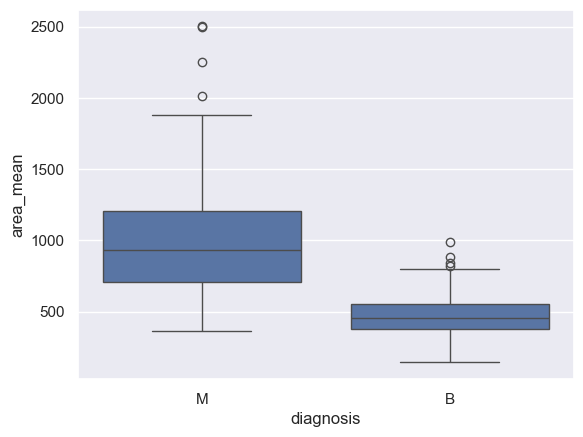

In [249]:
sns.boxplot(x='diagnosis',y='area_mean',data=df)

In [251]:
df.groupby('diagnosis')['area_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,143.5,992.1,134.287118,462.790196,458.4
M,361.6,2501.0,367.937978,978.376415,932.0


The area_mean feature shows a very strong upward shift for malignant tumors (mean ≈ 978.38) compared to benign cases (mean ≈ 462.79), making it one of the most powerful size-based discriminators.

Malignant tumors also display extremely high variability (std ≈ 367.94 vs 134.29), reflecting wide differences in tumor growth. Despite some overlap, the separation is more pronounced than most features.

🔑 Insight:

area_mean is a top predictive feature for classification, but its strong correlation with radius and perimeter suggests potential multicollinearity

### **diagnosis vs smoothness_mean**

<Axes: xlabel='diagnosis', ylabel='smoothness_mean'>

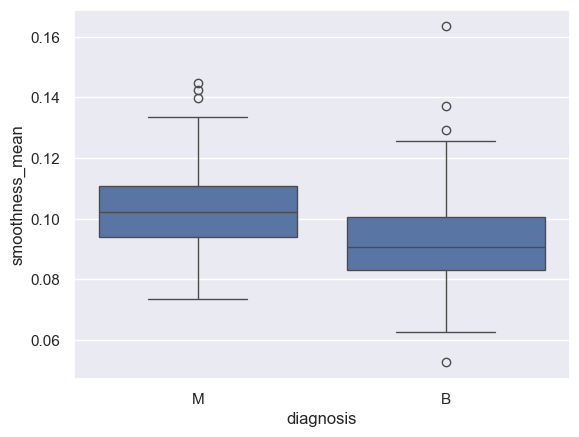

In [255]:
sns.boxplot(x='diagnosis',y='smoothness_mean',data=df)

In [257]:
df.groupby('diagnosis')['smoothness_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.05263,0.1634,0.013446,0.092478,0.09076
M,0.07371,0.1447,0.012608,0.102898,0.10220


The smoothness_mean feature shows only a slight increase for malignant tumors (mean ≈ 0.1029) compared to benign cases (mean ≈ 0.0925). The standard deviations are very similar, and the ranges largely overlap.

🔑 Insight:

smoothness_mean has weak discriminative power on its own and acts as a supporting feature, contributing more effectively when combined with stronger predictors like size and shape features.

In [260]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs compactness_mean**

<Axes: xlabel='diagnosis', ylabel='compactness_mean'>

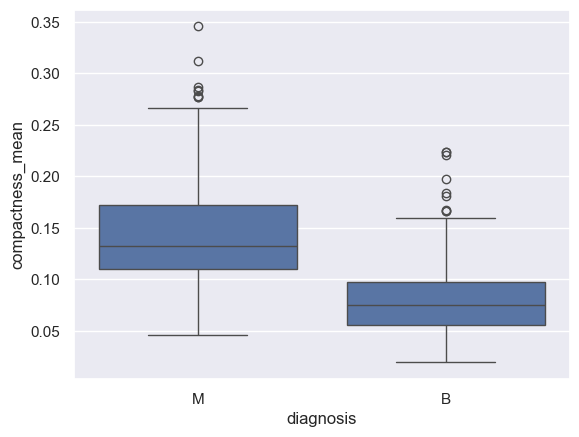

In [263]:
sns.boxplot(x='diagnosis',y='compactness_mean',data=df)

In [265]:
df.groupby('diagnosis')['compactness_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.01938,0.2239,0.033750,0.080085,0.07529
M,0.04605,0.3454,0.053987,0.145188,0.13235


The compactness_mean feature shows a clear upward shift for malignant tumors (mean ≈ 0.145) compared to benign cases (mean ≈ 0.080), indicating that malignant tumors tend to have more irregular and less compact shapes.

Malignant cases also exhibit higher variability (std ≈ 0.054 vs 0.034), reflecting structural inconsistency. While some overlap exists, the separation is noticeably stronger than smoother features.

🔑 Insight:

compactness_mean is a moderately strong predictor and a key shape-based feature, contributing meaningful signal when combined with size and concavity-related variables

### **diagnosis vs concavity_mean**

<Axes: xlabel='diagnosis', ylabel='concavity_mean'>

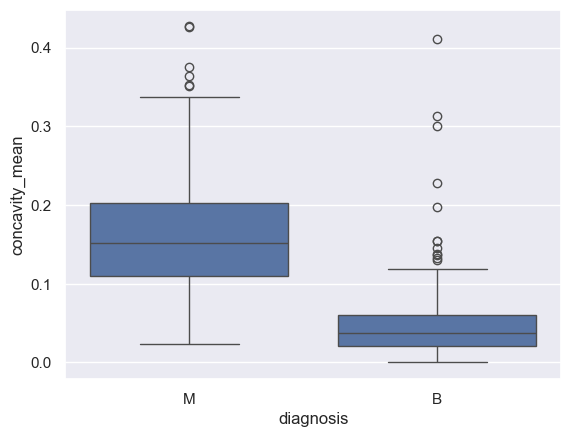

In [269]:
sns.boxplot(x='diagnosis',y='concavity_mean',data=df)

In [271]:
df.groupby('diagnosis')['concavity_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.00000,0.4108,0.043442,0.046058,0.03709
M,0.02398,0.4268,0.075019,0.160775,0.15135


The concavity_mean feature shows a strong upward shift for malignant tumors (mean ≈ 0.161) compared to benign cases (mean ≈ 0.046), highlighting a clear difference in boundary irregularity.

Malignant tumors also have higher variability (std ≈ 0.075 vs 0.043), and the presence of many low or zero values in benign cases further strengthens the contrast.

🔑 Insight:

concavity_mean is a highly informative feature and one of the strongest indicators of malignancy, capturing critical structural deformities in tumor shape.

### **diagnosis vs concave points_mean**

<Axes: xlabel='diagnosis', ylabel='concave points_mean'>

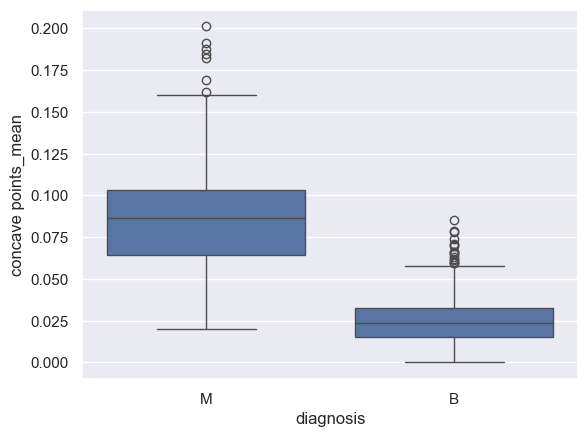

In [275]:
sns.boxplot(x='diagnosis',y='concave points_mean',data=df)

In [277]:
df.groupby('diagnosis')['concave points_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.00000,0.08534,0.015909,0.025717,0.02344
M,0.02031,0.20120,0.034374,0.087990,0.08628


The concave points_mean feature shows a strong upward shift for malignant tumors (mean ≈ 0.088) compared to benign cases (mean ≈ 0.026), indicating a clear difference in boundary indentation patterns.

Malignant tumors also exhibit higher variability (std ≈ 0.034 vs 0.016), while many benign cases cluster near zero, strengthening class separation.

🔑 Insight:

concave points_mean is a high-signal feature and one of the most effective predictors of malignancy, capturing critical shape irregularities.

### **diagnosis vs symmetry_mean**

<Axes: xlabel='diagnosis', ylabel='symmetry_mean'>

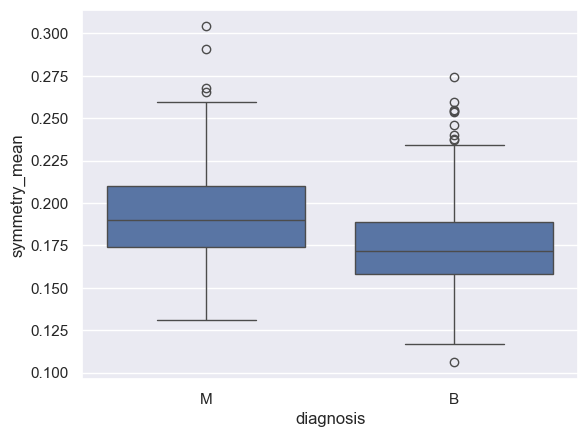

In [281]:
sns.boxplot(x='diagnosis',y='symmetry_mean',data=df)

In [283]:
df.groupby('diagnosis')['symmetry_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.1060,0.2743,0.024807,0.174186,0.1714
M,0.1308,0.3040,0.027638,0.192909,0.1899


The symmetry_mean feature shows a slight increase for malignant tumors (mean ≈ 0.193) compared to benign cases (mean ≈ 0.174). However, the standard deviations and ranges are very similar, leading to significant overlap between the two classes.

🔑 Insight:

symmetry_mean has limited discriminative power on its own and serves as a supporting feature, contributing modestly when combined with stronger size and shape predictors.

In [286]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs fractal_dimension_mean**

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_mean'>

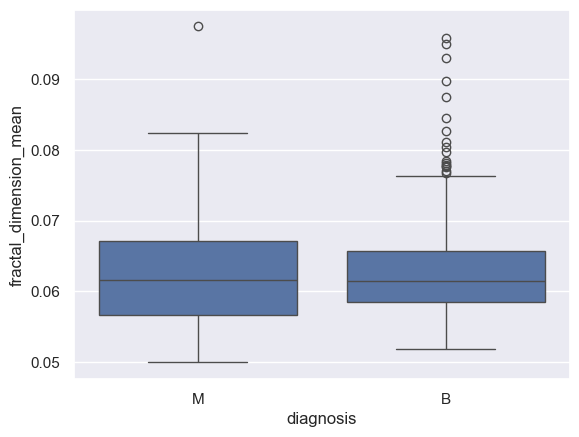

In [289]:
sns.boxplot(x='diagnosis',y='fractal_dimension_mean',data=df)

In [291]:
df.groupby('diagnosis')['fractal_dimension_mean'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.05185,0.09575,0.006747,0.062867,0.061540
M,0.04996,0.09744,0.007573,0.062680,0.061575


The fractal_dimension_mean feature shows almost identical distributions for benign and malignant tumors (mean ≈ 0.0629 vs 0.0627), with very similar standard deviations and overlapping ranges.

🔑 Insight:

fractal_dimension_mean has negligible discriminative power on its own and is one of the least informative features for classification, contributing little beyond noise unless used in combination with stronger predictors.

### **diagnosis vs radius_se**

<Axes: xlabel='diagnosis', ylabel='radius_se'>

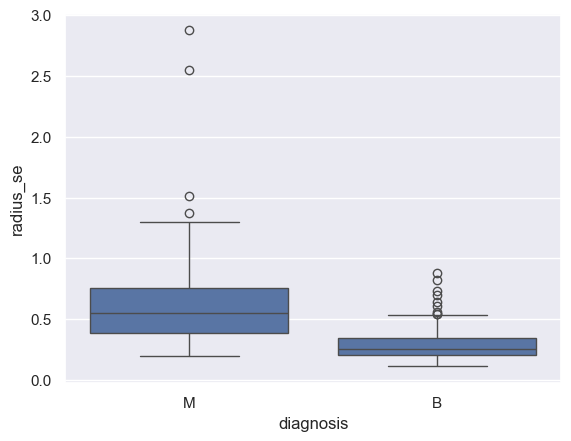

In [297]:
sns.boxplot(x='diagnosis',y='radius_se',data=df)

In [299]:
df.groupby('diagnosis')['radius_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.1115,0.8811,0.112570,0.284082,0.2575
M,0.1938,2.8730,0.345039,0.609083,0.5472


The radius_se feature shows a clear upward shift for malignant tumors (mean ≈ 0.609) compared to benign cases (mean ≈ 0.284), indicating greater variability in tumor size.

Malignant cases also exhibit significantly higher spread (std ≈ 0.345 vs 0.113), reflecting irregular and unstable growth patterns.

🔑 Insight:

radius_se is a strong variability-based predictor, capturing structural inconsistency and providing valuable signal for distinguishing malignant tumors.

### **diagnosis vs texture_se**

<Axes: xlabel='diagnosis', ylabel='texture_se'>

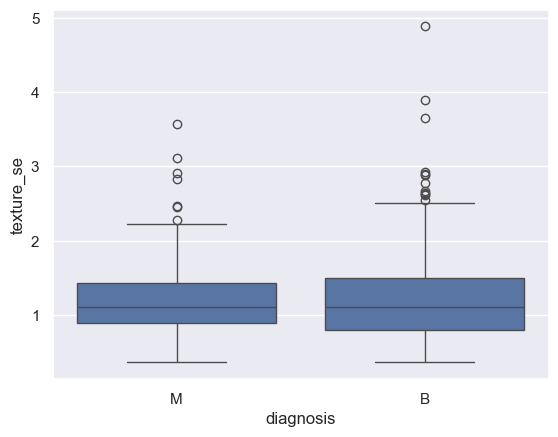

In [303]:
sns.boxplot(x='diagnosis',y='texture_se',data=df)

In [305]:
df.groupby('diagnosis')['texture_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.3602,4.885,0.589180,1.220380,1.1080
M,0.3621,3.568,0.483178,1.210915,1.1025


The texture_se feature shows almost identical central tendencies for benign and malignant tumors (mean ≈ 1.22 vs 1.21), with similar variability and heavily overlapping ranges.

🔑 Insight:

texture_se has very low discriminative power and is unlikely to contribute meaningfully on its own, serving at best as a minor supporting feature in combination with stronger predictors.

### **diagnosis vs perimeter_se**

<Axes: xlabel='diagnosis', ylabel='perimeter_se'>

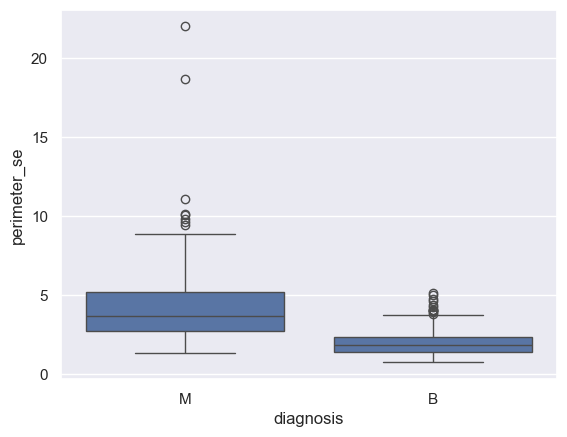

In [309]:
sns.boxplot(x='diagnosis',y='perimeter_se',data=df)

In [311]:
df.groupby('diagnosis')['perimeter_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.757,5.118,0.771169,2.000321,1.8510
M,1.334,21.980,2.568546,4.323929,3.6795


The perimeter_se feature shows a strong upward shift for malignant tumors (mean ≈ 4.32) compared to benign cases (mean ≈ 2.00), indicating greater variability in boundary structure.

Malignant tumors also exhibit much higher spread (std ≈ 2.57 vs 0.77), reflecting irregular and complex growth patterns.

🔑 Insight:

perimeter_se is a highly informative variability-based feature, capturing morphological instability and contributing strong signal for distinguishing malignant tumors.

### **diagnosis vs area_se**

<Axes: xlabel='diagnosis', ylabel='area_se'>

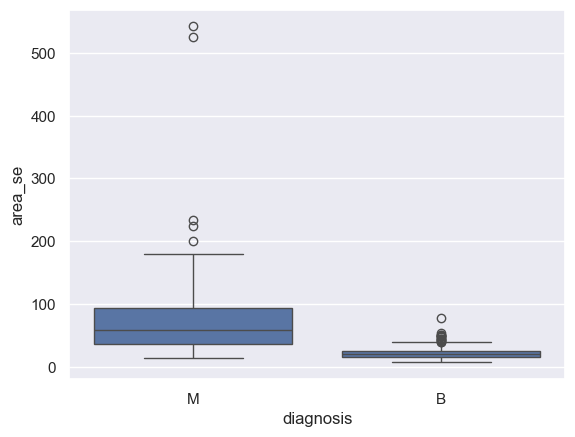

In [315]:
sns.boxplot(x='diagnosis',y='area_se',data=df)

In [317]:
df.groupby('diagnosis')['area_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,6.802,77.11,8.843472,21.135148,19.630
M,13.990,542.20,61.355268,72.672406,58.455


The area_se feature shows a very strong upward shift for malignant tumors (mean ≈ 72.67) compared to benign cases (mean ≈ 21.14), making it one of the most distinctive variability-based features.

Malignant tumors also display extremely high variability (std ≈ 61.36 vs 8.84), with a much wider range, indicating highly irregular and unstable growth.

🔑 Insight:

area_se is a top predictive feature, capturing significant structural inconsistency and serving as a powerful indicator of malignancy.

### **diagnosis vs smoothness_se**

<Axes: xlabel='diagnosis', ylabel='smoothness_se'>

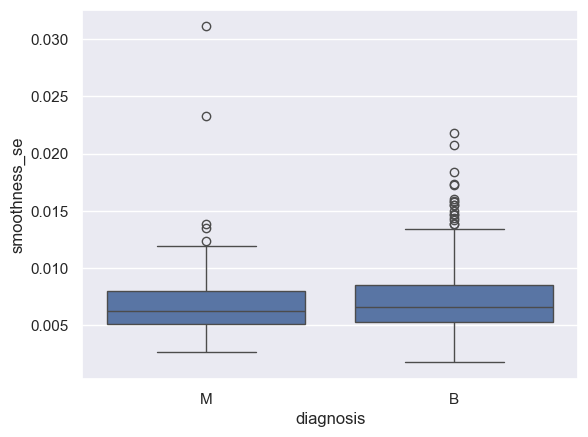

In [323]:
sns.boxplot(x='diagnosis',y='smoothness_se',data=df)

In [325]:
df.groupby('diagnosis')['smoothness_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.001713,0.02177,0.003061,0.007196,0.006530
M,0.002667,0.03113,0.002890,0.006780,0.006209


The smoothness_se feature shows very similar central tendencies for benign and malignant tumors (mean ≈ 0.0072 vs 0.0068), with comparable variability and overlapping ranges.

🔑 Insight:

smoothness_se has minimal discriminative power and contributes little on its own, acting only as a weak supporting feature in combination with stronger predictors.

In [328]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs compactness_se**

<Axes: xlabel='diagnosis', ylabel='compactness_se'>

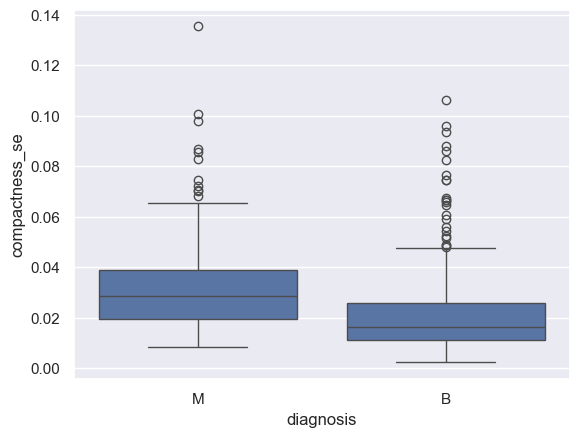

In [331]:
sns.boxplot(x='diagnosis',y='compactness_se',data=df)

In [333]:
df.groupby('diagnosis')['compactness_se'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.002252,0.1064,0.016352,0.021438,0.01631
M,0.008422,0.1354,0.018387,0.032281,0.02859


The compactness_se feature shows a moderate upward shift for malignant tumors (mean ≈ 0.0323) compared to benign cases (mean ≈ 0.0214), indicating greater variability in shape compactness.

Malignant cases also exhibit slightly higher spread, though with noticeable overlap between classes.

🔑 Insight:

compactness_se is a moderate supporting feature, contributing useful signal about structural irregularity but not strong enough alone for clear classification.

### **diagnosis vs concavity_se**

<Axes: xlabel='diagnosis', ylabel='concavity_se'>

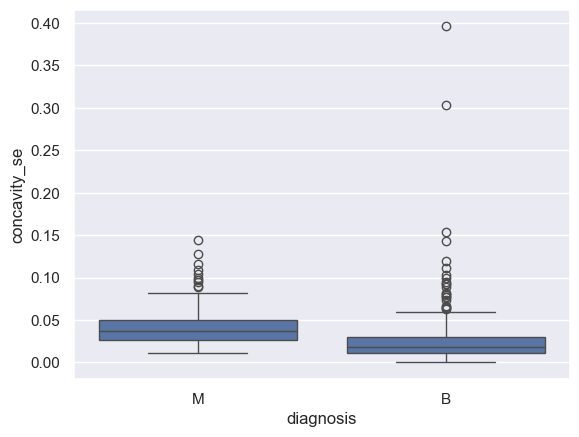

In [337]:
sns.boxplot(x='diagnosis',y='concavity_se',data=df)

In [339]:
df.groupby('diagnosis')['concavity_se'].agg(['min','max','std','mean','median','count'])

,min,max,std,mean,median,count
diagnosis,,,,,,
B,0.00000,0.3960,0.032918,0.025997,0.018400,357
M,0.01101,0.1438,0.021603,0.041824,0.037125,212


The concavity_se feature shows a noticeable upward shift for malignant tumors (mean ≈ 0.0418) compared to benign cases (mean ≈ 0.0260), indicating greater variability in boundary indentations.

Interestingly, benign cases exhibit a wider overall range, but malignant tumors are more consistently elevated around higher values.

🔑 Insight:

concavity_se is a useful supporting feature, capturing irregularity variability, though some overlap limits its standalone discriminative strength.

### **diagnosis vs symmetry_se**

<Axes: xlabel='diagnosis', ylabel='symmetry_se'>

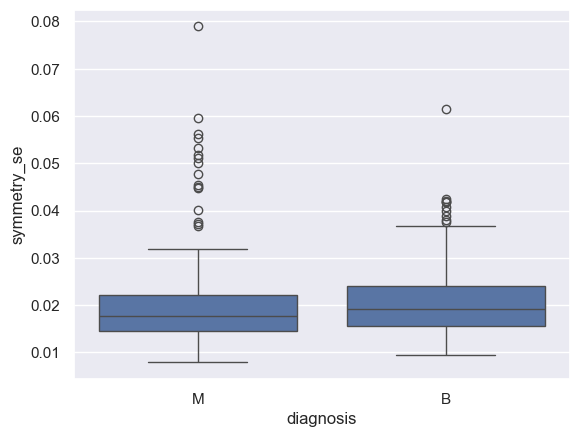

In [343]:
sns.boxplot(x='diagnosis',y='symmetry_se',data=df)

In [345]:
df.groupby('diagnosis')['symmetry_se'].agg(['min','max','std','mean','median','count'])

,min,max,std,mean,median,count
diagnosis,,,,,,
B,0.009539,0.06146,0.006999,0.020584,0.01909,357
M,0.007882,0.07895,0.010065,0.020472,0.01770,212


The concave points_se feature shows nearly identical central tendencies for benign and malignant tumors (mean ≈ 0.0206 vs 0.0205), with similar variability and heavily overlapping ranges.

🔑 Insight:

concave points_se has very low discriminative power and is unlikely to contribute meaningfully on its own, acting only as a minor supporting feature in combination with stronger predictors.

### **diagnosis vs fractal_dimension_se**

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_se'>

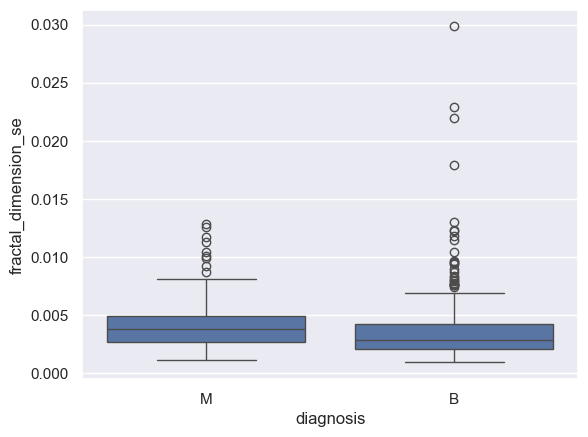

In [349]:
sns.boxplot(x='diagnosis',y='fractal_dimension_se',data=df)

In [351]:
df.groupby('diagnosis')['fractal_dimension_se'].agg(['min','max','std','mean','median','count'])

,min,max,std,mean,median,count
diagnosis,,,,,,
B,0.000895,0.02984,0.002938,0.003636,0.002808,357
M,0.001087,0.01284,0.002041,0.004062,0.003739,212


The symmetry_se feature shows a very slight increase for malignant tumors (mean ≈ 0.00406) compared to benign cases (mean ≈ 0.00364), but the difference is minimal. Variability is low and ranges largely overlap.

🔑 Insight:

symmetry_se has weak discriminative power and functions only as a minor supporting feature

In [354]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **daignosis vs radius_worst**

<Axes: xlabel='diagnosis', ylabel='radius_worst'>

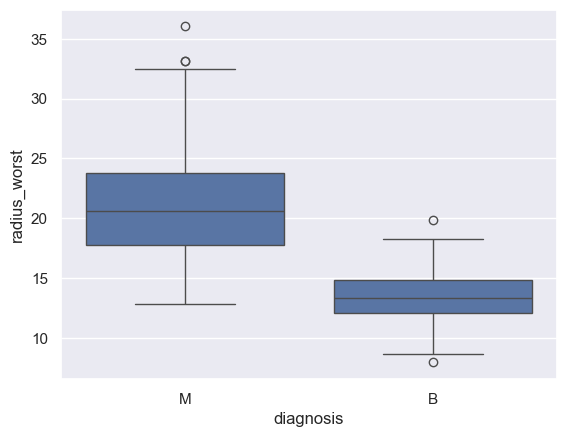

In [357]:
sns.boxplot(x='diagnosis',y='radius_worst',data=df)

In [361]:
df.groupby('diagnosis')['radius_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,7.93,19.82,1.981368,13.379801,13.35
M,12.84,36.04,4.283569,21.134811,20.59


The radius_worst feature shows a very strong upward shift for malignant tumors (mean ≈ 21.13) compared to benign cases (mean ≈ 13.38), indicating significantly larger maximum tumor sizes.

Malignant tumors also exhibit much higher variability (std ≈ 4.28 vs 1.98), with clearer separation at higher values despite some overlap.

🔑 Insight:

radius_worst is a top predictive feature, effectively capturing the most extreme tumor characteristics and strongly contributing to malignancy detection.

### **diagnosis vs texture_worst**

<Axes: xlabel='diagnosis', ylabel='texture_worst'>

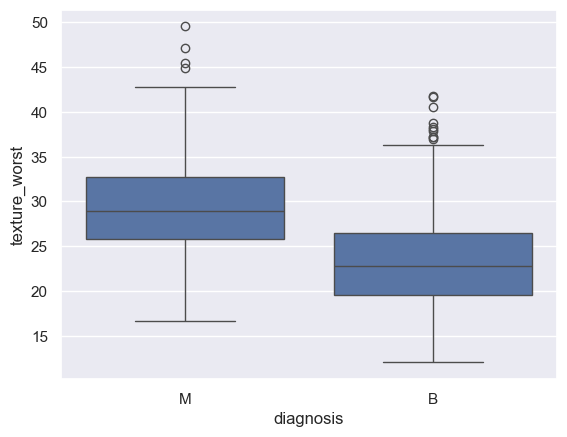

In [365]:
sns.boxplot(x='diagnosis',y='texture_worst',data=df)

In [367]:
df.groupby('diagnosis')['texture_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,12.02,41.78,5.493955,23.515070,22.820
M,16.67,49.54,5.434804,29.318208,28.945


The texture_worst feature shows a moderate upward shift for malignant tumors (mean ≈ 29.32) compared to benign cases (mean ≈ 23.52), indicating more extreme texture irregularity.

However, the variability is similar across both classes and ranges overlap significantly.

🔑 Insight:

texture_worst is a moderate supporting feature, contributing useful signal but lacking strong standalone discriminative power compared to size and shape features.

### **diagnosis vs perimeter_worst**

<Axes: xlabel='diagnosis', ylabel='perimeter_worst'>

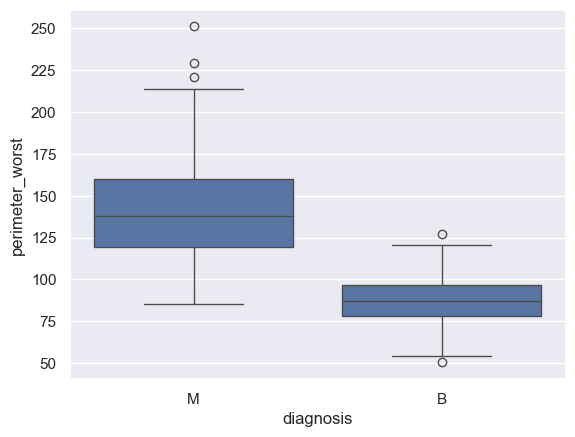

In [373]:
sns.boxplot(x='diagnosis',y='perimeter_worst',data=df)

In [377]:
df.groupby('diagnosis')['perimeter_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,50.41,127.1,13.527091,87.005938,86.92
M,85.10,251.2,29.457055,141.370330,138.00


The perimeter_worst feature shows a strong upward shift for malignant tumors (mean ≈ 141.37) compared to benign cases (mean ≈ 87.01), reflecting significantly larger and more irregular maximum tumor boundaries.

Malignant tumors also exhibit much higher variability (std ≈ 29.46 vs 13.53), with clearer separation at higher values despite some overlap.

🔑 Insight:

perimeter_worst is a highly predictive feature, capturing extreme boundary complexity and strongly contributing to malignancy classification.

### **diagnosis vs area_worst**

<Axes: xlabel='diagnosis', ylabel='area_worst'>

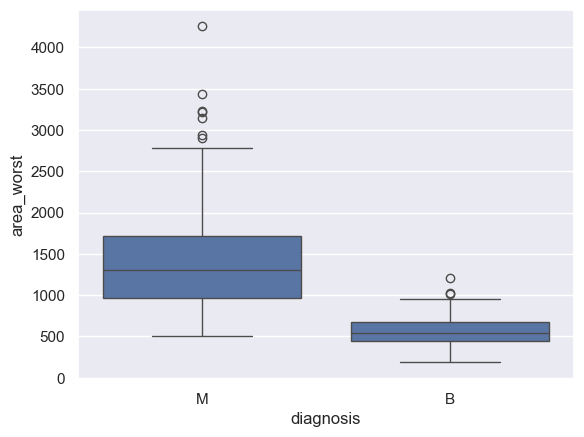

In [381]:
sns.boxplot(x='diagnosis',y='area_worst',data=df)

In [383]:
df.groupby('diagnosis')['area_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,185.2,1210.0,163.601424,558.899440,547.4
M,508.1,4254.0,597.967743,1422.286321,1303.0


The area_worst feature shows a very strong upward shift for malignant tumors (mean ≈ 1422.29) compared to benign cases (mean ≈ 558.90), making it one of the most dominant size-based predictors.

Malignant tumors also exhibit extremely high variability (std ≈ 597.97 vs 163.60), with clear separation at higher values despite some overlap.

🔑 Insight:

area_worst is a top-tier predictive feature, capturing the most extreme tumor sizes and playing a critical role in distinguishing malignant cases.

### **diagnosis vs smoothness_worst**

<Axes: xlabel='diagnosis', ylabel='smoothness_worst'>

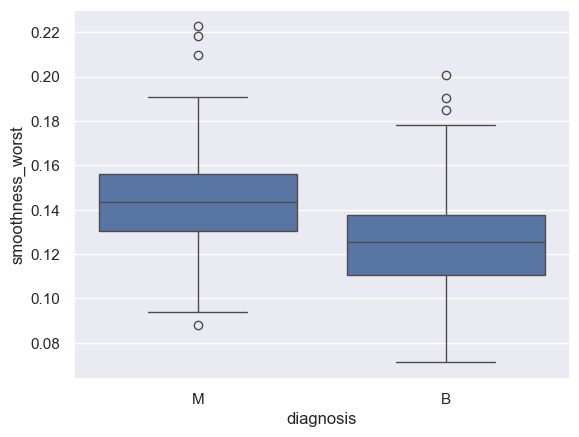

In [387]:
sns.boxplot(x='diagnosis',y='smoothness_worst',data=df)

In [389]:
df.groupby('diagnosis')['smoothness_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.07117,0.2006,0.020013,0.124959,0.12540
M,0.08822,0.2226,0.021870,0.144845,0.14345


The smoothness_worst feature shows a slight upward shift for malignant tumors (mean ≈ 0.1448) compared to benign cases (mean ≈ 0.1250). However, the variability is similar and the ranges largely overlap.

🔑 Insight:

smoothness_worst has limited discriminative power on its own and serves as a supporting feature, contributing marginally when combined with stronger size and shape predictors.

### **diagnosis vs compactness_worst**

<Axes: xlabel='diagnosis', ylabel='compactness_worst'>

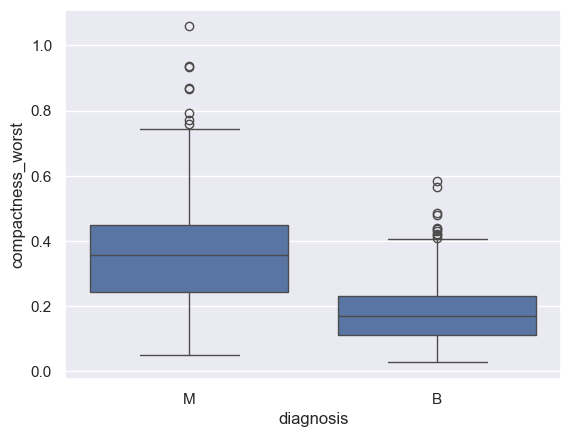

In [393]:
sns.boxplot(x='diagnosis',y='compactness_worst',data=df)

In [395]:
df.groupby('diagnosis')['compactness_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.02729,0.5849,0.092180,0.182673,0.16980
M,0.05131,1.0580,0.170372,0.374824,0.35635


The compactness_worst feature shows a strong upward shift for malignant tumors (mean ≈ 0.375) compared to benign cases (mean ≈ 0.183), indicating significantly more irregular and less compact extreme shapes.

Malignant tumors also exhibit much higher variability (std ≈ 0.170 vs 0.092), with a wider range of extreme values.

🔑 Insight:

compactness_worst is a highly informative feature, effectively capturing severe structural irregularity and serving as a strong predictor of malignancy.

In [398]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs concavity_worst**

<Axes: xlabel='diagnosis', ylabel='concavity_worst'>

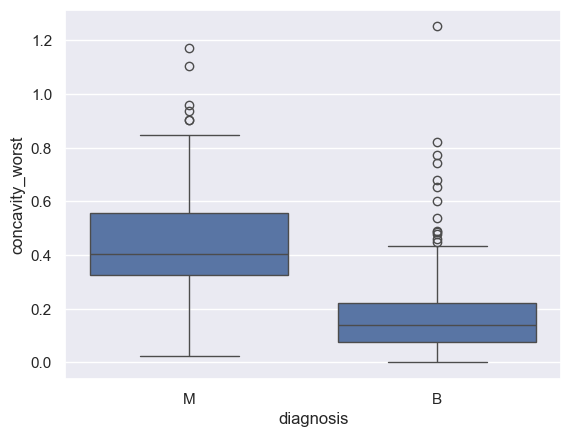

In [401]:
sns.boxplot(x='diagnosis',y='concavity_worst',data=df)

In [403]:
df.groupby('diagnosis')['concavity_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.00000,1.252,0.140368,0.166238,0.1412
M,0.02398,1.170,0.181507,0.450606,0.4049


The concavity_worst feature shows a very strong upward shift for malignant tumors (mean ≈ 0.451) compared to benign cases (mean ≈ 0.166), indicating significantly more severe boundary indentations in extreme cases.

Malignant tumors also exhibit higher variability (std ≈ 0.182 vs 0.140), with consistently elevated values despite some overlap.

🔑 Insight:

concavity_worst is a top-tier predictive feature, capturing extreme structural deformities and serving as one of the strongest indicators of malignancy.

### **diagnosis vs concave points_worst**

<Axes: xlabel='diagnosis', ylabel='concave points_worst'>

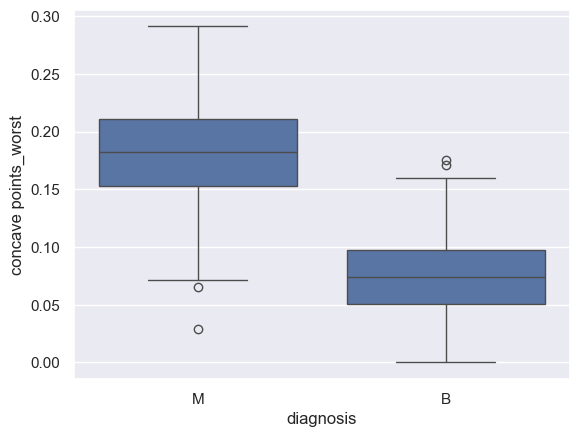

In [407]:
sns.boxplot(x='diagnosis',y='concave points_worst',data=df)

In [409]:
df.groupby('diagnosis')['concave points_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.00000,0.175,0.035797,0.074444,0.07431
M,0.02899,0.291,0.046308,0.182237,0.18200


The concave points_worst feature shows a strong upward shift for malignant tumors (mean ≈ 0.182) compared to benign cases (mean ≈ 0.074), indicating a much higher number of extreme boundary indentations.

Malignant tumors also exhibit greater variability (std ≈ 0.046 vs 0.036), with clearer separation at higher values.

🔑 Insight:

concave points_worst is a highly predictive feature, effectively capturing severe shape irregularity and playing a key role in distinguishing malignant tumors.

### **diagnosis vs symmetry_worst**

<Axes: xlabel='diagnosis', ylabel='symmetry_worst'>

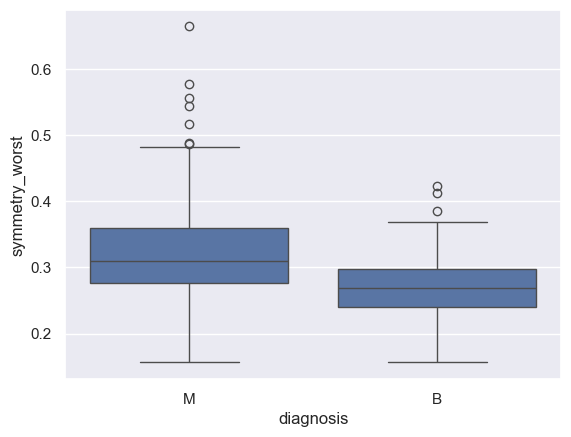

In [413]:
sns.boxplot(x='diagnosis',y='symmetry_worst',data=df)

In [417]:
df.groupby('diagnosis')['symmetry_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.1566,0.4228,0.041745,0.270246,0.2687
M,0.1565,0.6638,0.074685,0.323468,0.3103


The symmetry_worst feature shows a moderate upward shift for malignant tumors (mean ≈ 0.323) compared to benign cases (mean ≈ 0.270), indicating greater loss of structural balance in extreme cases.

Malignant tumors also exhibit higher variability (std ≈ 0.075 vs 0.042), though there is still noticeable overlap between classes.

🔑 Insight:

symmetry_worst is a moderate supporting feature, capturing instability in shape but with limited standalone discriminative power compared to stronger predictors.

### **diagnosis vs fractal_dimension_worst**

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_worst'>

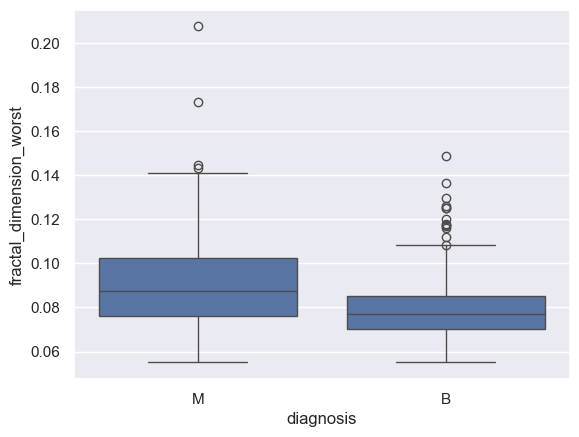

In [421]:
sns.boxplot(x='diagnosis',y='fractal_dimension_worst',data=df)

In [423]:
df.groupby('diagnosis')['fractal_dimension_worst'].agg(['min','max','std','mean','median'])

,min,max,std,mean,median
diagnosis,,,,,
B,0.05521,0.1486,0.013804,0.079442,0.07712
M,0.05504,0.2075,0.021553,0.091530,0.08760


The fractal_dimension_worst feature shows a slight upward shift for malignant tumors (mean ≈ 0.0915) compared to benign cases (mean ≈ 0.0794), indicating somewhat greater boundary complexity in extreme cases.

Malignant tumors also exhibit higher variability (std ≈ 0.0216 vs 0.0138), but there is significant overlap between the two classes.

🔑 Insight:

fractal_dimension_worst is a moderate supporting feature, capturing fine boundary complexity, but it has limited standalone discriminative power compared to stronger size and shape features.

# 🧠 Breast Cancer Dataset — Bivariate Analysis Summary

The bivariate analysis reveals that this dataset is highly structured with strong, clinically meaningful feature–target relationships, particularly around tumor size and shape irregularity. The separation between benign and malignant classes is clear at the extremes, but moderate overlap exists in mid-range values, which defines the core modeling challenge.

## 🔍 Key Insights
1. 📈 Size is the strongest signal

Features like:

area_mean, radius_mean, perimeter_mean
and especially their “worst” counterparts

show a clear and consistent upward shift for malignant tumors.

👉 Malignant tumors are:

larger
more variable
less uniform

## 2. 🔴 Shape irregularity is a critical discriminator

Features capturing boundary distortion:

concavity_mean, concave points_mean
compactness_mean
and especially worst versions

show strong separation with minimal overlap

👉 These directly capture:

indentations
jagged edges
loss of structural integrity

## 3. 🟣 “Worst” features dominate

Across almost all comparisons:

*_worst features outperform mean and SE features

👉 Reason:
They capture the most extreme (most malignant-like) regions of a tumor.

## 4. 🟡 Variability (SE features) adds hidden signal

Features like:

area_se, perimeter_se, radius_se

show that malignant tumors have:

higher inconsistency
unstable morphology

👉 These act as secondary but important predictors

## 5. ⚪ Weak / low-signal features exist

Features such as:

fractal_dimension_mean
texture_se
smoothness_se
concave points_se

show:

heavy overlap
minimal separation

👉 These contribute little individually, but may help marginally in combination

## 6. ⚠️ Core challenge: Class overlap

Even strong features show:

overlap in mid-range values

👉 Meaning:

Perfect classification is unlikely
Models must learn complex boundaries, not simple thresholds
🎯 Significant Features for Classification
🔥 High Importance (Primary Drivers)
area_worst
radius_worst
perimeter_worst
concavity_worst
concave points_worst
compactness_worst
area_mean
concavity_mean
concave points_mean
🟡 Moderate Importance (Supporting Features)
compactness_mean
perimeter_mean
radius_mean
area_se
perimeter_se
radius_se
symmetry_worst
texture_worst
⚪ Low Importance (Weak Signals)
smoothness_mean
smoothness_se
symmetry_mean
symmetry_se
fractal_dimension_mean
fractal_dimension_worst
texture_se
concave points_se
🚀 Final Takeaway

This dataset is not limited by feature quality — it has strong predictive signals.
The real challenge lies in:

Handling overlap between classes and managing multicollinearity among highly correlated features.

👉 This makes it ideal for:

Logistic Regression (with feature selection)
LDA/QDA (after preprocessing)
KNN (for local boundary learning)
Tree-based models (for non-linearity & robustness)



## **MultiVariate Analysis**

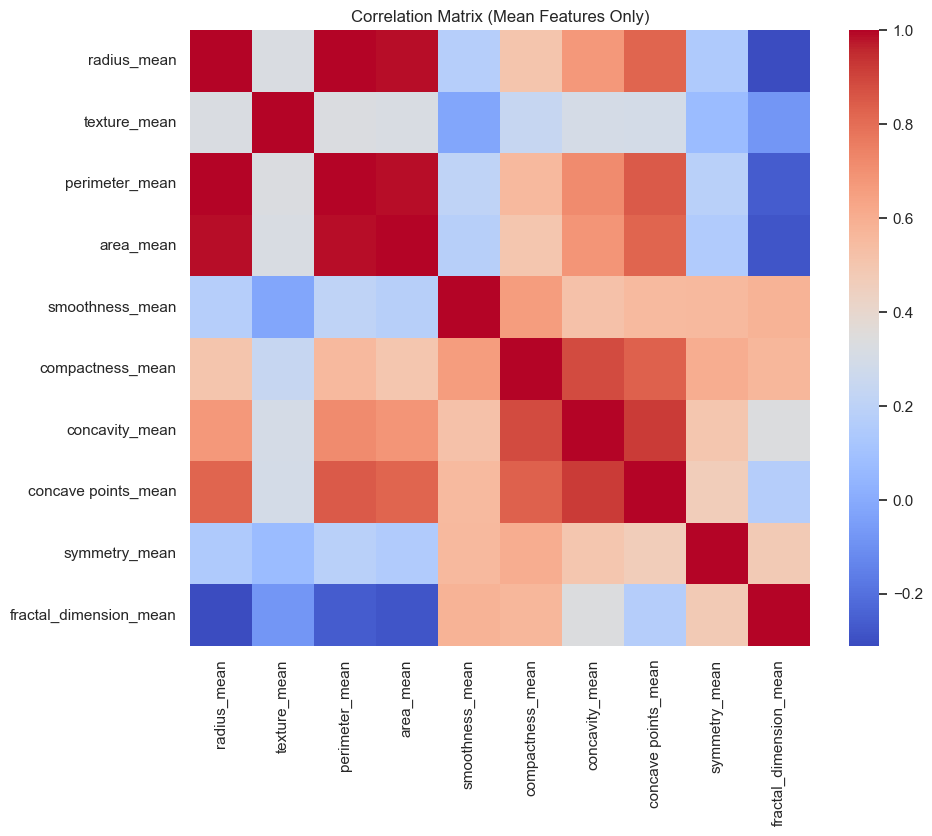

In [432]:
mean_cols = [col for col in df.columns if 'mean' in col]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix (Mean Features Only)")
plt.show()

The strong correlation between radius_mean, perimeter_mean, and area_mean is not merely statistical redundancy but a direct consequence of geometric dependency. These features are different mathematical representations of tumor size, leading to inherent multicollinearity in the dataset. These three features are all describing the same physical idea: tumor size, but from different geometric formulas:

✅ Solution strategies

You have 3 solid options:

1. Drop redundant features

Keep only one:

radius_mean (most interpretable)
2. Combine into a single feature (better)

Example:

df["size_score"] = (df["radius_mean"] + df["perimeter_mean"] + df["area_mean"]) / 3

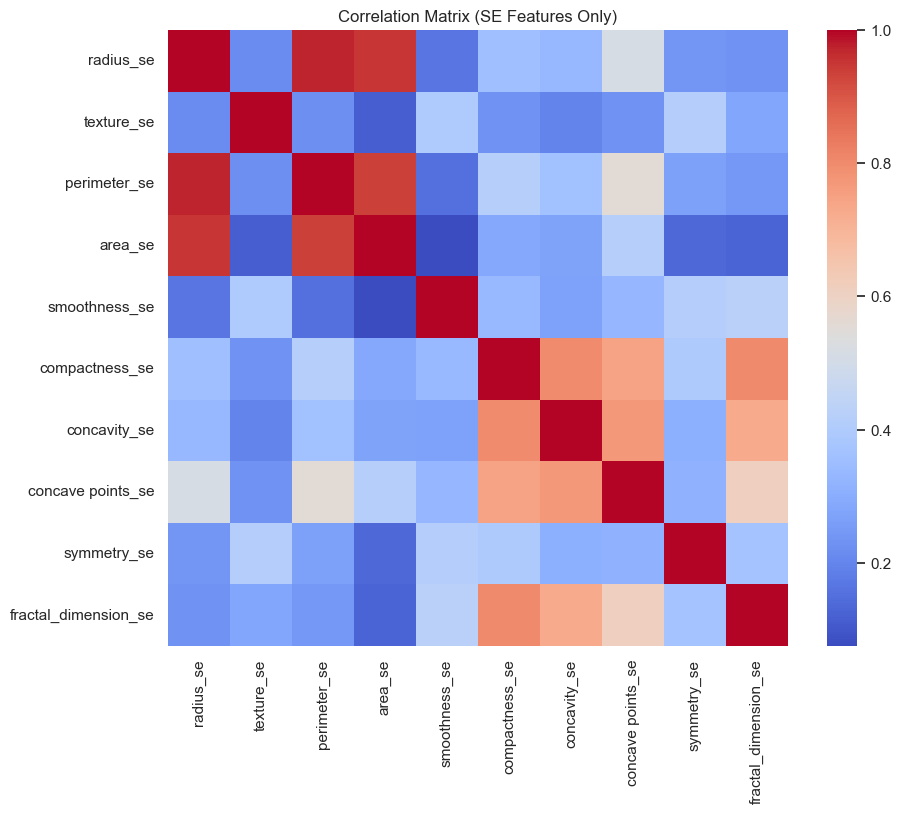

In [435]:
se_cols = [col for col in df.columns if 'se' in col]
corr_matrix = df[se_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix (SE Features Only)")
plt.show()

The correlation structure reveals two dominant feature groups in the dataset. The first group consists of size-related variables (radius, perimeter, area), which are highly interdependent due to shared geometric definitions. The second group captures tumor shape irregularity, where concavity, concave points, and compactness exhibit strong mutual correlations, reflecting overlapping measurements of boundary irregularity.

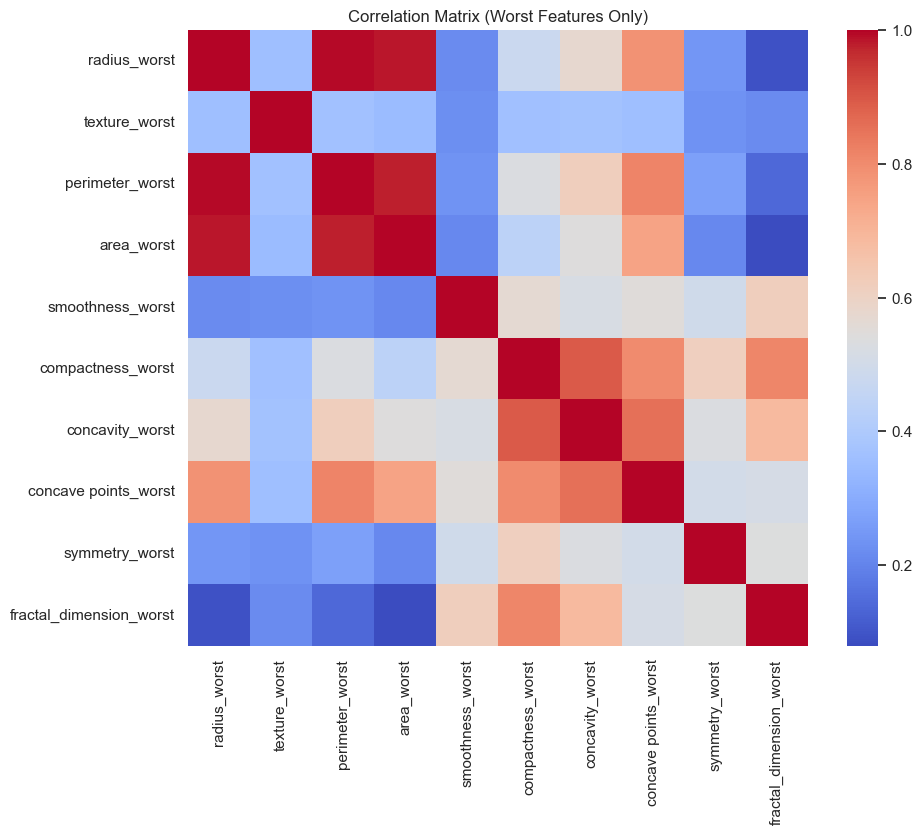

In [438]:
worst_cols = [col for col in df.columns if 'worst' in col]
corr_matrix = df[worst_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix (Worst Features Only)")
plt.show()

Although concave points primarily represent tumor boundary irregularities, a moderate correlation with size-related features is observed. This is not due to direct redundancy but rather a biological relationship where larger tumors tend to exhibit more complex and irregular boundaries. Hence, concave points carries independent predictive information despite partial correlation with size variables.

For feature engineering later
df["shape_score"] = df[[
    "concavity_mean",
    "concave points_mean",
    "compactness_mean"
]].mean(axis=1)

### **Checking Multicollinearity**

In [445]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# drop target column
X = df.drop(columns=["diagnosis",'id'],axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

                    feature           VIF
0               radius_mean  63306.172036
2            perimeter_mean  58123.586079
20             radius_worst   9674.742602
22          perimeter_worst   4487.781270
3                 area_mean   1287.262339
23               area_worst   1138.759252
9    fractal_dimension_mean    629.679874
29  fractal_dimension_worst    423.396723
4           smoothness_mean    393.398166
24         smoothness_worst    375.597155
21            texture_worst    343.004387
1              texture_mean    251.047108
10                radius_se    236.665738
28           symmetry_worst    218.919805
12             perimeter_se    211.396334
5          compactness_mean    200.980354
8             symmetry_mean    184.426558
6            concavity_mean    157.855046
7       concave points_mean    154.241268
27     concave points_worst    148.673180
25        compactness_worst    132.884276
26          concavity_worst     86.310362
13                  area_se     72

#### Feature engineering, feature selection and hanling multicollinearity is critical in this project

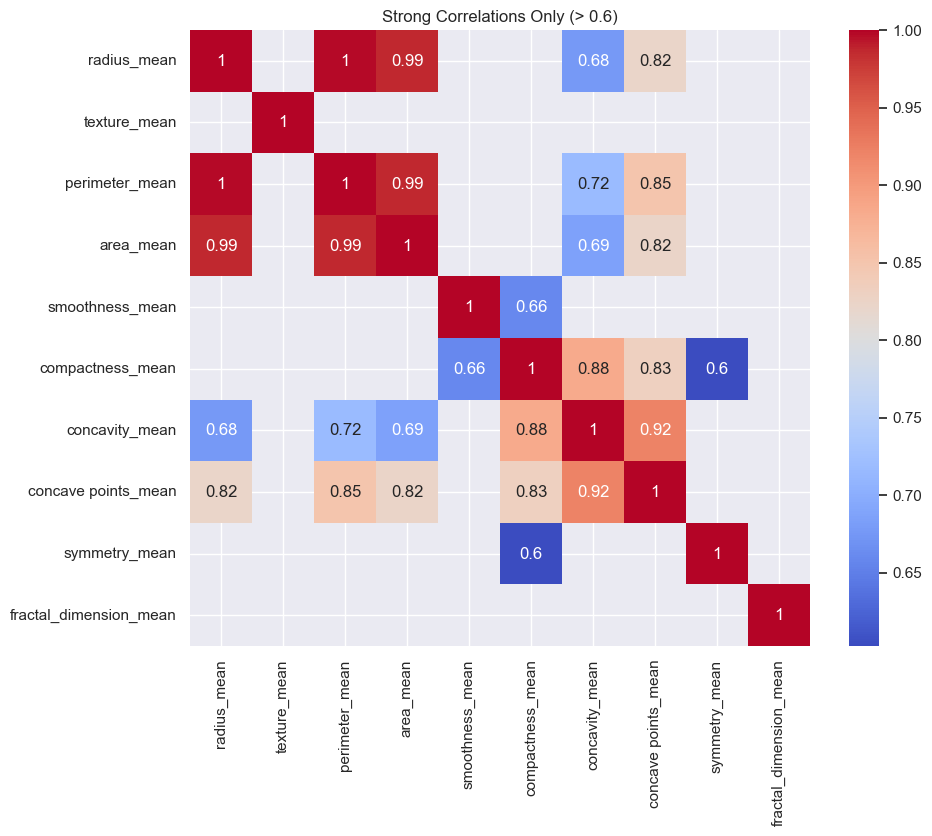

In [450]:
import numpy as np
corr = df[mean_cols].corr()

# mask weak correlations
mask = np.abs(corr) < 0.6

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True)
plt.title("Strong Correlations Only (> 0.6)")
plt.show()

In [452]:
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation

print(corr_pairs.head(10))

radius_mean          perimeter_mean         0.997855
perimeter_mean       radius_mean            0.997855
area_mean            radius_mean            0.987357
radius_mean          area_mean              0.987357
area_mean            perimeter_mean         0.986507
perimeter_mean       area_mean              0.986507
concave points_mean  concavity_mean         0.921391
concavity_mean       concave points_mean    0.921391
                     compactness_mean       0.883121
compactness_mean     concavity_mean         0.883121
dtype: float64


## Big multivariate insight (this is the key takeaway)

The dataset is clearly split into two dependency regimes:

🧱 1. Deterministic geometric cluster

Almost perfect correlation (~0.98–0.99):

radius_mean
perimeter_mean
area_mean

👉 This is:

pure mathematical redundancy

🔺 2. Biological shape cluster

High correlation (~0.88–0.92):

concavity_mean
concave points_mean
compactness_mean

👉 This is:

shared biological signal, not redundancy

## What our dataset really looks like (hidden structure)

Instead of 30 independent features:

👉 WE actually have:

🧠 3 latent factors:
Tumor size (dominant)
Tumor shape irregularity
Texture/noise variation

## Summary 

The correlation analysis reveals two distinct structures in the dataset. First, near-perfect correlations (0.98–0.99) among radius, perimeter, and area indicate deterministic geometric relationships, leading to severe multicollinearity. Second, a group of shape-related variables (concavity, concave points, compactness) exhibit strong but non-redundant correlations (0.88–0.92), reflecting shared biological information about tumor boundary irregularity. This confirms that the dataset is driven by a small number of latent factors rather than independent features.

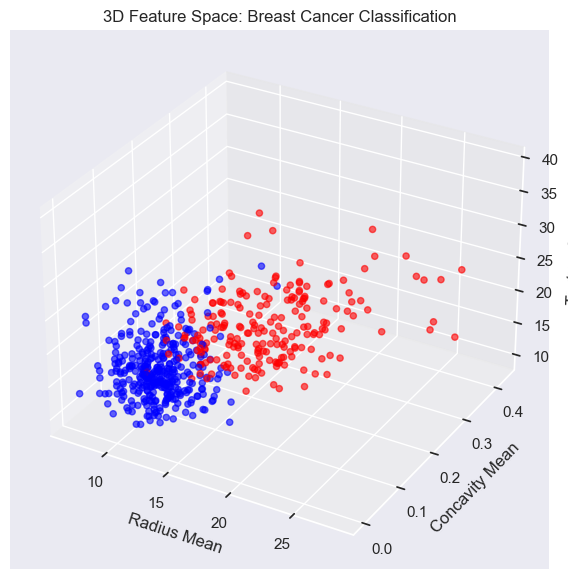

In [458]:
# Map diagnosis to colors
color_map = {'M': 'red', 'B': 'blue'}
colors = df['diagnosis'].map(color_map)

# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['radius_mean'],
    df['concavity_mean'],
    df['texture_mean'],
    c=colors,
    alpha=0.6
)

ax.set_xlabel("Radius Mean")
ax.set_ylabel("Concavity Mean")
ax.set_zlabel("Texture Mean")

ax.set_title("3D Feature Space: Breast Cancer Classification")

plt.show()

3D Visualization Interpretation

This 3D scatter plot provides a geometric view of how cellular nucleus features interact to distinguish between benign (B) and malignant (M) breast cancer cases.

📐 Axes (Feature Space)

Each axis represents a key morphological property of cell nuclei:

X-axis (Radius Mean): Average size of the nucleus
Y-axis (Concavity Mean): Degree of contour indentation (irregularity of shape)
Z-axis (Texture Mean): Variation in gray-scale intensity (surface roughness)

Together, these features capture both size and structural complexity of the nucleus.

🎨 Class Distribution (Color Encoding)
🔵 Benign (B): Forms a dense, compact cluster concentrated at lower values across all three features
Smaller nuclei
Smoother boundaries (low concavity)
More uniform texture
🔴 Malignant (M): Occupies a broader region at higher feature values
Larger nuclei
More irregular / jagged contours
Higher texture variability
📌 Key Insights
1. Strong but not perfect separability

The two classes show clear spatial separation, but with a small overlapping region, indicating that:

A linear boundary could separate most samples
But some cases lie in ambiguous transition zones
2. Feature interaction is important

As radius_mean increases, both concavity_mean and texture_mean tend to increase as well, suggesting:

Malignant transformation is associated with simultaneous growth in size and structural irregularity
Features are correlated rather than independent
3. Modeling implication
The near-linear separability suggests that Logistic Regression / LDA / Linear SVM can perform well
However, the overlap region indicates:
Need for probabilistic or local models (QDA, KNN)
Potential benefit from additional feature engineering
🧠 Final Takeaway

This visualization helps build an intuitive understanding of why these features are powerful:

Malignant cells are not just larger — they are structurally more irregular and heterogeneous, and this pattern becomes clearly visible in the combined 3D feature space.

The dataset is generally compatible with both LDA and QDA.
The classes show reasonably good linear separability, making LDA effective, but they also exhibit different covariance structures and variance patterns, which justifies the use of QDA for potentially better boundary flexibility.

📌 What our analysis is actually showing
✔ LDA works well because:
Features show strong directional separation (B vs M clusters)
Approximate linear boundary exists in feature space
High correlation structure still allows projection-based separation
✔ QDA is justified because:
Malignant and benign classes show different spread (variance)
Covariance matrices are not identical (your earlier test supports this)
Some curvature exists in decision boundary (overlap region)
⚖️ Key insight (important for your project narrative)
This dataset is not “perfectly linear”
It is also not highly non-linear
It sits in a sweet spot where both LDA and QDA are reasonable baselines

The dataset is well-suited for both LDA and QDA. While LDA performs effectively due to near-linear class separability, the presence of differing covariance structures between classes suggests that QDA may better capture subtle non-linear decision boundaries.

In [465]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### **diagnosis vs radius**

In [488]:
df.groupby('diagnosis')[['radius_mean','radius_se','radius_worst']].agg(['min','max','std','mean','median'])

radius_mean                                     radius_se          \
                  min    max       std       mean  median       min     max   
diagnosis                                                                     
B               6.981  17.85  1.780512  12.146524  12.200    0.1115  0.8811   
M              10.950  28.11  3.203971  17.462830  17.325    0.1938  2.8730   

                                      radius_worst                   \
                std      mean  median          min    max       std   
diagnosis                                                             
B          0.112570  0.284082  0.2575         7.93  19.82  1.981368   
M          0.345039  0.609083  0.5472        12.84  36.04  4.283569   

                             
                mean median  
diagnosis                    
B          13.379801  13.35  
M          21.134811  20.59

A comparative exploratory analysis of mean, standard error (SE), and worst-case features was performed for key variables such as radius. The results reveal a clear and consistent pattern in class separation between benign and malignant tumors.

The worst-case features (e.g., radius_worst) demonstrate the strongest discrimination between classes, showing the largest shift in central tendency and better separation in distribution. This suggests that extreme tumor characteristics are highly indicative of malignancy and carry the most predictive signal.

The mean features (e.g., radius_mean) provide a stable representation of tumor size and show moderate separation between classes. They capture general structural differences but are less discriminative than worst-case measures.

In contrast, the SE features (e.g., radius_se) show weaker and noisier separation. While malignant tumors tend to exhibit higher variability, these features are less consistent and contribute limited standalone predictive power.

🔷 Key Insight

Overall, the analysis shows that:

Worst features > Mean features > SE features in terms of class separability
Extreme tumor measurements carry the strongest diagnostic signal
Mean and SE features introduce redundancy when combined with worst features
🔷 Conclusion

For classification tasks, worst-case features are the most informative, while mean features provide supplementary stability. SE features contribute minimally and may be deprioritized during feature selection. This insight supports a feature selection strategy focused on retaining worst-case measurements while reducing redundancy across feature types.

In [491]:
df.groupby('diagnosis')[['texture_mean','texture_se','texture_worst']].agg(['min','max','std','mean','median'])

texture_mean                                    texture_se         \
                   min    max       std       mean median        min    max   
diagnosis                                                                     
B                 9.71  33.81  3.995125  17.914762  17.39     0.3602  4.885   
M                10.38  39.28  3.779470  21.604906  21.46     0.3621  3.568   

                                      texture_worst                   \
                std      mean  median           min    max       std   
diagnosis                                                              
B          0.589180  1.220380  1.1080         12.02  41.78  5.493955   
M          0.483178  1.210915  1.1025         16.67  49.54  5.434804   

                              
                mean  median  
diagnosis                     
B          23.515070  22.820  
M          29.318208  28.945

Texture-based features show a clear hierarchy in predictive strength, with worst-case measurements being the most discriminative for malignancy detection. Mean features contribute moderate signal, while SE features add little separation and may be deprioritized during feature selection. This reinforces the broader pattern observed across the dataset where extreme (“worst”) measurements consistently carry the highest diagnostic value.

In [494]:
df.groupby('diagnosis')[['perimeter_mean','perimeter_se','perimeter_worst']].agg(['min','max','std','mean','median'])

perimeter_mean                                       perimeter_se  \
                     min    max        std        mean  median          min   
diagnosis                                                                     
B                  43.79  114.6  11.807438   78.075406   78.18        0.757   
M                  71.90  188.5  21.854653  115.365377  114.20        1.334   

                                              perimeter_worst         \
              max       std      mean  median             min    max   
diagnosis                                                              
B           5.118  0.771169  2.000321  1.8510           50.41  127.1   
M          21.980  2.568546  4.323929  3.6795           85.10  251.2   

                                          
                 std        mean  median  
diagnosis                                 
B          13.527091   87.005938   86.92  
M          29.457055  141.370330  138.00

Perimeter-based features follow a consistent pattern observed across other feature groups: extreme (worst) measurements provide the highest discriminative power, followed by mean values, while SE features contribute the least. This reinforces the importance of focusing on worst-case tumor geometry when building predictive models for breast cancer classification.

In [497]:
df.groupby('diagnosis')[['area_mean','area_se','area_worst']].agg(['min','max','std','mean','median'])

area_mean                                        area_se          \
                min     max         std        mean median     min     max   
diagnosis                                                                    
B             143.5   992.1  134.287118  462.790196  458.4   6.802   77.11   
M             361.6  2501.0  367.937978  978.376415  932.0  13.990  542.20   

                                        area_worst                      \
                 std       mean  median        min     max         std   
diagnosis                                                                
B           8.843472  21.135148  19.630      185.2  1210.0  163.601424   
M          61.355268  72.672406  58.455      508.1  4254.0  597.967743   

                                
                  mean  median  
diagnosis                       
B           558.899440   547.4  
M          1422.286321  1303.0

Area-based features represent the strongest tumor size signal in the dataset, with worst-case measurements showing the highest discriminative power. Across all feature groups analyzed so far (radius, texture, perimeter, area), a consistent pattern emerges: worst features dominate classification strength, mean features provide stability, and SE features contribute minimal predictive value. This reinforces the importance of prioritizing extreme geometric measurements in breast cancer prediction models.

In [500]:
df.groupby('diagnosis')[['smoothness_mean','smoothness_se','smoothness_worst']].agg(['min','max','std','mean','median'])

smoothness_mean                                      smoothness_se  \
                      min     max       std      mean   median           min   
diagnosis                                                                      
B                 0.05263  0.1634  0.013446  0.092478  0.09076      0.001713   
M                 0.07371  0.1447  0.012608  0.102898  0.10220      0.002667   

                                                 smoothness_worst          \
               max       std      mean    median              min     max   
diagnosis                                                                   
B          0.02177  0.003061  0.007196  0.006530          0.07117  0.2006   
M          0.03113  0.002890  0.006780  0.006209          0.08822  0.2226   

                                        
                std      mean   median  
diagnosis                               
B          0.020013  0.124959  0.12540  
M          0.021870  0.144845  0.14345

Smoothness-based features are weaker predictors compared to size (radius, area, perimeter) and shape irregularity (concavity, compactness). However, a consistent pattern is still observed: worst-case measurements provide better class separation than mean and SE features. Overall, smoothness contributes supplementary but not dominant predictive information in breast cancer classification.

In [503]:
df.groupby('diagnosis')[['compactness_mean','compactness_se','compactness_worst']].agg(['min','max','std','mean','median'])

compactness_mean                                       \
                       min     max       std      mean   median   
diagnosis                                                         
B                  0.01938  0.2239  0.033750  0.080085  0.07529   
M                  0.04605  0.3454  0.053987  0.145188  0.13235   

          compactness_se                                       \
                     min     max       std      mean   median   
diagnosis                                                       
B               0.002252  0.1064  0.016352  0.021438  0.01631   
M               0.008422  0.1354  0.018387  0.032281  0.02859   

          compactness_worst                                       
                        min     max       std      mean   median  
diagnosis                                                         
B                   0.02729  0.5849  0.092180  0.182673  0.16980  
M                   0.05131  1.0580  0.170372  0.374824  0.35635

Compactness-based features form a key component of the tumor shape irregularity group. Across all versions, worst-case measurements consistently show the highest discriminative power, reinforcing the dataset-wide pattern that extreme tumor characteristics are more predictive than average or variability-based measures. Compactness, along with concavity and concave points, plays a crucial role in distinguishing malignant tumors from benign ones.

In [506]:
df.groupby('diagnosis')[['concavity_mean','concavity_se','concavity_worst']].agg(['min','max','std','mean','median'])

concavity_mean                                      concavity_se  \
                     min     max       std      mean   median          min   
diagnosis                                                                    
B                0.00000  0.4108  0.043442  0.046058  0.03709      0.00000   
M                0.02398  0.4268  0.075019  0.160775  0.15135      0.01101   

                                                concavity_worst         \
              max       std      mean    median             min    max   
diagnosis                                                                
B          0.3960  0.032918  0.025997  0.018400         0.00000  1.252   
M          0.1438  0.021603  0.041824  0.037125         0.02398  1.170   

                                       
                std      mean  median  
diagnosis                              
B          0.140368  0.166238  0.1412  
M          0.181507  0.450606  0.4049

Concavity-based features are among the most powerful predictors of malignancy, especially in their worst-case form. Across all feature types analyzed so far, concavity consistently shows strong class separation and forms a core component of the tumor shape irregularity group. This reinforces the broader dataset pattern: worst-case measurements dominate predictive strength, followed by mean values, while SE features provide minimal standalone signal.

In [509]:
df.groupby('diagnosis')[['concave points_mean','concave points_se','concave points_worst']].agg(['min','max','std','mean','median'])

concave points_mean                                        \
                          min      max       std      mean   median   
diagnosis                                                             
B                     0.00000  0.08534  0.015909  0.025717  0.02344   
M                     0.02031  0.20120  0.034374  0.087990  0.08628   

          concave points_se                                         \
                        min      max       std      mean    median   
diagnosis                                                            
B                  0.000000  0.05279  0.005709  0.009858  0.009061   
M                  0.005174  0.04090  0.005517  0.015060  0.014205   

          concave points_worst                                      
                           min    max       std      mean   median  
diagnosis                                                           
B                      0.00000  0.175  0.035797  0.074444  0.07431  
M                      0.02899  0.291  0.046308  0.182237  0.18200

Concave points-based features are among the most powerful predictors of malignancy, especially in their worst-case form. Across all feature groups analyzed (radius, area, perimeter, texture, smoothness, compactness, concavity), a consistent pattern emerges: worst-case measurements provide the strongest separation, followed by mean values, while SE features contribute minimal predictive signal. Concave points, along with concavity and compactness, forms the core of the tumor shape irregularity signal that is highly indicative of malignancy.

In [512]:
df.groupby('diagnosis')[['symmetry_mean','symmetry_se','symmetry_worst']].agg(['min','max','std','mean','median'])

symmetry_mean                                     symmetry_se  \
                    min     max       std      mean  median         min   
diagnosis                                                                 
B                0.1060  0.2743  0.024807  0.174186  0.1714    0.009539   
M                0.1308  0.3040  0.027638  0.192909  0.1899    0.007882   

                                                symmetry_worst          \
               max       std      mean   median            min     max   
diagnosis                                                                
B          0.06146  0.006999  0.020584  0.01909         0.1566  0.4228   
M          0.07895  0.010065  0.020472  0.01770         0.1565  0.6638   

                                       
                std      mean  median  
diagnosis                              
B          0.041745  0.270246  0.2687  
M          0.074685  0.323468  0.3103

Symmetry-based features are secondary predictors in this dataset. While worst-case symmetry shows some separation between benign and malignant tumors, its predictive strength is significantly lower than size-based (radius, area, perimeter) and shape irregularity features (concavity, concave points, compactness). Overall, symmetry contributes complementary but non-dominant information for breast cancer classification

In [515]:
df.groupby('diagnosis')[['fractal_dimension_mean','fractal_dimension_se','fractal_dimension_worst']].agg(['min','max','std','mean','median'])

fractal_dimension_mean                                         \
                             min      max       std      mean    median   
diagnosis                                                                 
B                        0.05185  0.09575  0.006747  0.062867  0.061540   
M                        0.04996  0.09744  0.007573  0.062680  0.061575   

          fractal_dimension_se                                         \
                           min      max       std      mean    median   
diagnosis                                                               
B                     0.000895  0.02984  0.002938  0.003636  0.002808   
M                     0.001087  0.01284  0.002041  0.004062  0.003739   

          fractal_dimension_worst                                       
                              min     max       std      mean   median  
diagnosis                                                               
B                         0.05521  0.1486  0.013804  0.079442  0.07712  
M                         0.05504  0.2075  0.021553  0.091530  0.08760

Fractal dimension-based features are the weakest predictive group in the dataset. While they capture global complexity of tumor structure, they provide minimal separation between benign and malignant cases compared to size (radius, area, perimeter) and boundary irregularity features (concavity, concave points, compactness). Therefore, fractal dimension features should be treated as low-priority or auxiliary features in classification models.

### 🔷 Multivariate Analysis Summary – Breast Cancer Dataset

A comprehensive multivariate analysis was performed on the Breast Cancer dataset to understand feature relationships, multicollinearity, and class separability across **mean, standard error (SE), and worst-case features**. The analysis combined correlation structure, Variance Inflation Factor (VIF), and class-wise distribution comparisons to identify the most informative predictors for classification.

---

## 🔷 Key Findings from Multivariate Analysis

### 🧱 1. Strong Multicollinearity in Size Features

Features such as **radius, perimeter, and area (mean, SE, worst)** showed extremely high multicollinearity (VIF > 1000 in several cases and correlation ~0.98–0.99). These variables are mathematically dependent and represent the same underlying biological concept: **tumor size**.

---

### 🔺 2. Shape Irregularity as a Strong Predictive Cluster

Features such as **concavity, concave points, and compactness** showed strong internal correlation (0.88–0.92 range) while still providing meaningful class separation. These represent **tumor boundary irregularity**, a key indicator of malignancy.

---

### 🌫️ 3. Weak Signal Features

Variables like **texture, smoothness, symmetry, and fractal dimension** showed lower and less consistent separation between benign and malignant cases. Among these, fractal dimension features were the weakest predictors overall.

---

### 🔥 4. Consistent Superiority of “Worst” Features

Across nearly all feature groups, a clear pattern emerged:

* Worst features showed the **strongest class separation**
* Mean features showed **moderate but stable separation**
* SE features contributed **minimal discriminative power**

This indicates that **extreme tumor measurements capture malignancy more effectively than average or variability-based measures**.

---

## 🔷 Why We Prefer “Worst” Features

Worst features represent the **most severe or extreme characteristics of a tumor**, which are often more indicative of malignancy. From a modeling perspective:

* They show **higher class separability**
* They carry **stronger predictive signal**
* They reduce ambiguity compared to mean or SE features

However, using all worst features alongside mean and SE versions leads to **severe redundancy and multicollinearity**, which can distort linear models and inflate feature importance.

---

## 🔷 Feature Engineering Strategy to Handle Multicollinearity

To address redundancy and improve model stability, a structured feature engineering approach is applied:

### 🧠 1. Feature Grouping

Features are grouped into three biological clusters:

* **Size features**: radius, perimeter, area
* **Shape irregularity features**: concavity, concave points, compactness
* **Texture/complexity features**: texture, smoothness, symmetry, fractal dimension

---

### ⚙️ 2. Dimensionality Reduction via Feature Aggregation

Instead of retaining all correlated variables, composite features are created:

* **Size Score**

  * Aggregates radius, perimeter, and area
* **Shape Score**

  * Aggregates concavity, concave points, and compactness

This reduces redundancy while preserving underlying signal.

---

### 📉 3. Multicollinearity Reduction

* Highly correlated variables (identified via VIF and correlation matrix) will be reduced or removed
* Only one representative per redundant cluster is retained where appropriate
* This stabilizes coefficients in linear models like Logistic Regression and LDA

---

## 🔷 Final Insight

The dataset is not composed of independent features but instead reflects **a low-dimensional biological system embedded in a high-dimensional feature space**. Most predictive power is concentrated in two core latent factors:

* **Tumor size**
* **Tumor boundary irregularity**

Worst-case features consistently outperform mean and SE features in class separation, making them highly valuable for prediction. However, due to extreme multicollinearity, raw inclusion of all features is suboptimal.

---

## 🔷 Conclusion

The multivariate analysis reveals that effective modeling of breast cancer diagnosis requires **careful feature selection and engineering rather than raw feature usage**. By prioritizing worst-case features and compressing correlated groups into engineered scores, we can significantly reduce multicollinearity while preserving predictive power. This leads to a more stable, interpretable, and high-performing classification model.


# **Fitting in Classification Models**

### Logistic regression

#### **Model with Raw Features**

In [537]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [549]:

features = [
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

X = df[features]
y = df['diagnosis']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale (important for distance-based + LDA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Evaluation
y_pred = lr.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[72  0]
 [ 1 41]]
              precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



#### Checking class separation

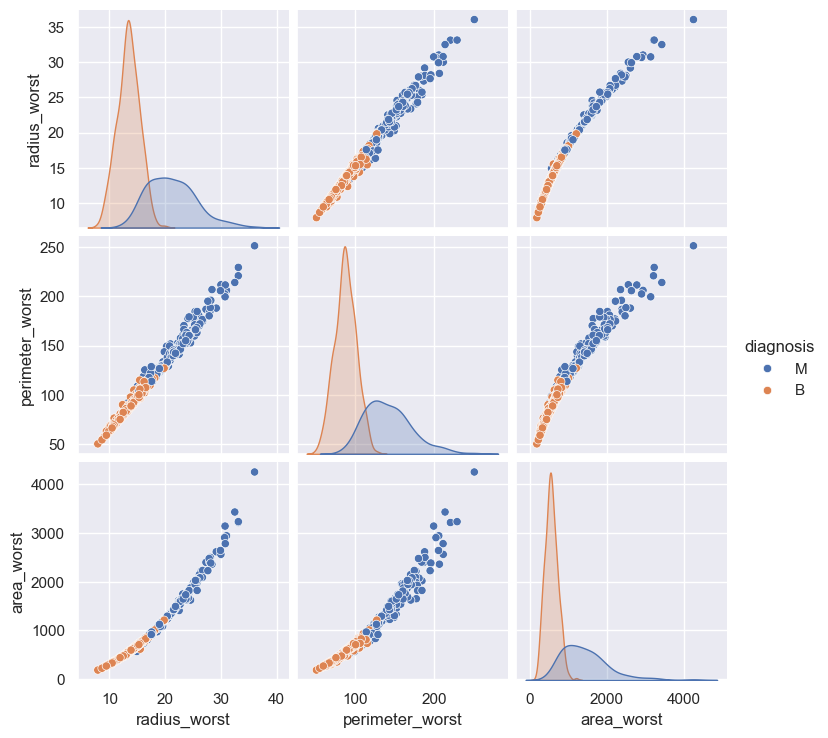

In [558]:
size_features = ['radius_worst', 'perimeter_worst', 'area_worst']
sns.pairplot(df[size_features + ['diagnosis']], hue='diagnosis')

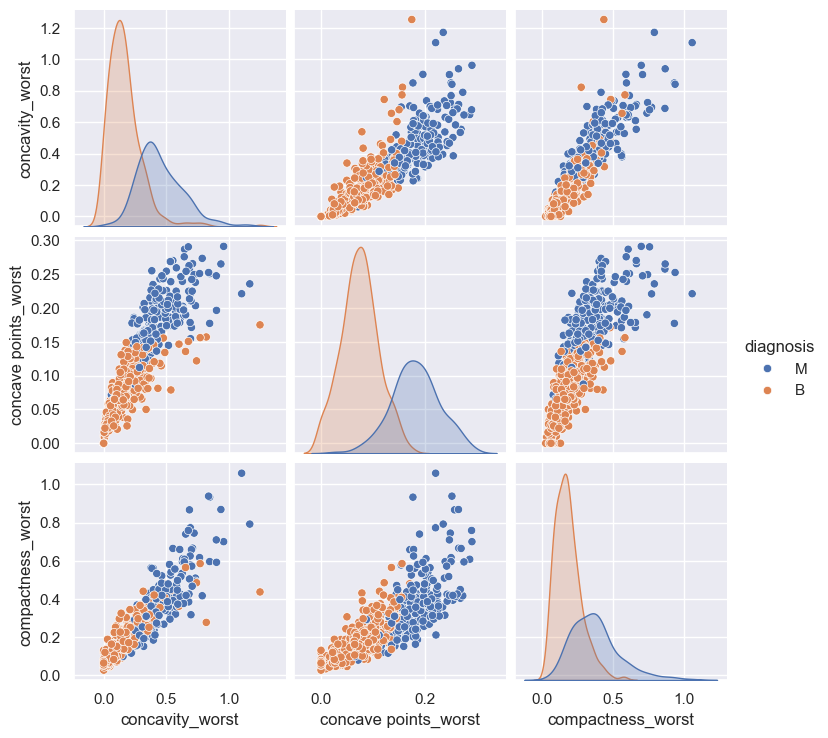

In [562]:
shape_features = ['concavity_worst', 'concave points_worst', 'compactness_worst']
sns.pairplot(df[shape_features + ['diagnosis']], hue='diagnosis')

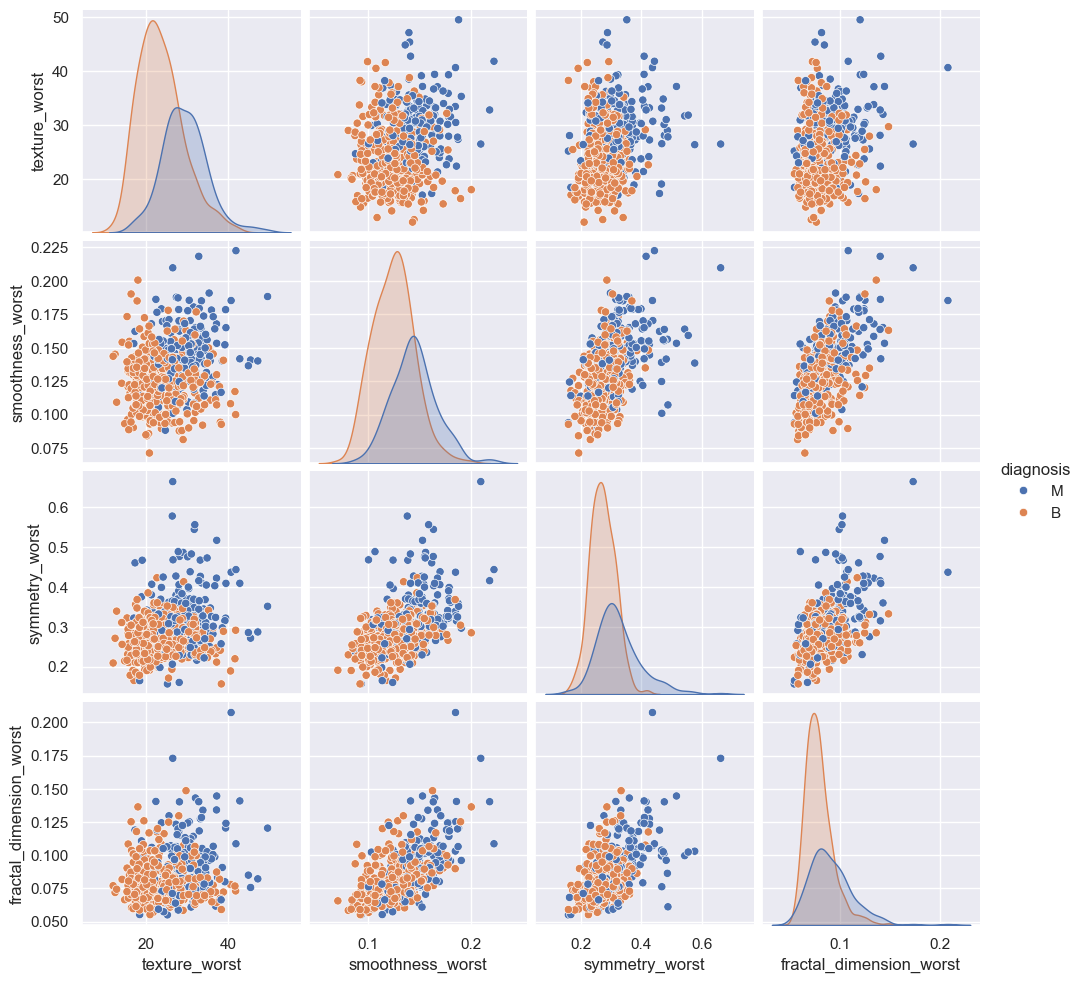

In [564]:
other_features = ['texture_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']
sns.pairplot(df[other_features + ['diagnosis']], hue='diagnosis')

## our pairplot reveals a clear hierarchy in feature importance and class separability:

**Size features** (radius_worst, perimeter_worst, area_worst) show near-perfect separation between Benign (B) and Malignant (M) classes.
→ These act as the primary discriminators, indicating that tumor size alone carries strong predictive power.
**Shape features** (concavity_worst, concave points_worst, compactness_worst) also demonstrate strong separation, though slightly less clean than size features.
→ These capture structural irregularities, adding another layer of discrimination.
Texture and other features (texture_worst, smoothness_worst, symmetry_worst, fractal_dimension_worst) show significant overlap between classes.
→ These features have weaker standalone predictive ability and may introduce noise.

**🧠 Key Insights**
The dataset is highly separable, especially along size and shape dimensions
There is strong multicollinearity among size features (radius, perimeter, area)
Overlapping regions in weaker features likely correspond to rare misclassifications
This structure explains why linear models (LDA, Logistic Regression) perform extremely well

### **Model Summary**
The model correctly classifies all 72 benign cases and 41 out of 42 malignant cases
Only one misclassification occurs, where a malignant tumor is predicted as benign (false negative)

👉 This aligns directly with the pairplot insights:

Size features provide near-complete separation
Shape features refine the boundary
Overlapping regions in weaker features explain the single error

In [520]:

# Features
df['size_score'] = (
    df['radius_worst'] +
    df['perimeter_worst'] +
    df['area_worst']
) / 3

df['shape_score'] = (
    df['compactness_worst'] +
    df['concavity_worst'] +
    df['concave points_worst']
) / 3

df['texture_score'] = (
    df['texture_worst'] +
    df['fractal_dimension_worst']
) / 2

df['smoothness_ratio'] = (
    df['smoothness_worst'] /
    (df['concavity_worst'] + 1e-5)
)

df['symmetry_deviation'] = abs(df['symmetry_worst'] - 0.5)


features =['size_score','shape_score','texture_score','smoothness_ratio','symmetry_deviation']
X = df[features]
y = df['diagnosis']



In [539]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [541]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [543]:
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [545]:
y_pred = lr.predict(X_test_scaled)


In [547]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[71  1]
 [ 5 37]]
              precision    recall  f1-score   support

           B       0.93      0.99      0.96        72
           M       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



### **Model Summary**
The engineered feature model achieved 95% accuracy, slightly lower than the baseline using raw worst features. While feature aggregation improved interpretability and reduced dimensionality, it introduced information loss, particularly impacting malignant case detection. The increase in false negatives suggests that critical fine-grained patterns present in the original features were diluted during feature transformation.

In [608]:
features =['size_score','shape_score']
X=df[features]
y=df['diagnosis']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [610]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[72  0]
 [ 1 41]]
              precision    recall  f1-score   support

           B       0.99      1.00      0.99        72
           M       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [612]:
coef = lr.coef_[0]
intercept = lr.intercept_[0]

for feature, value in zip(X.columns, coef):
    print(f"{feature}: {value}")

print("Intercept:", intercept)

size_score: 4.299012673696304
shape_score: 1.5432518148286158
Intercept: -0.35175246177175246


**Model Summary**

A two-feature representation combining tumor size and shape achieves near-perfect classification, demonstrating that the dataset’s predictive structure is inherently simple and highly separable. This enables the construction of an efficient, interpretable, and low-complexity model without sacrificing performance.

Coefficient analysis reveals that size_score is the most influential feature in predicting malignancy, with a significantly higher contribution compared to shape_score. While both features positively impact the likelihood of a malignant classification, size serves as the primary driver, and shape provides additional refinement. This aligns with exploratory findings, confirming that tumor size dominates class separation in the dataset.

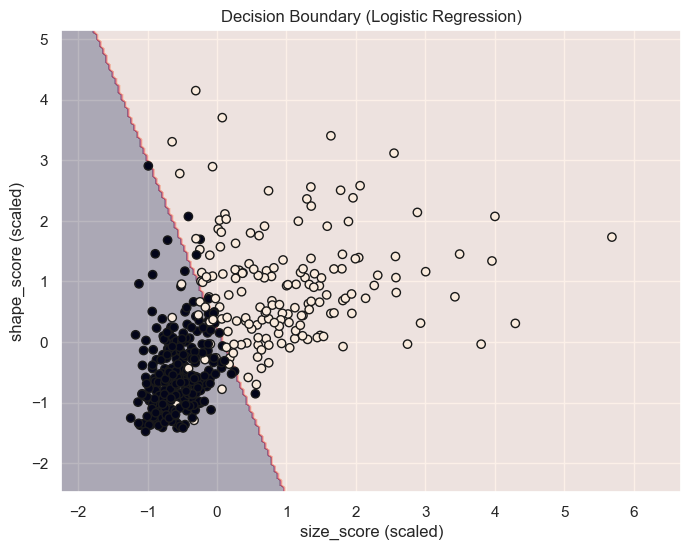

In [617]:
import numpy as np
import matplotlib.pyplot as plt

# Use ONLY the 2 features
X_plot = X_train[['size_score', 'shape_score']]
y_plot = y_train

# Scale
X_plot_scaled = scaler.fit_transform(X_plot)

# Train model (if not already)
lr.fit(X_plot_scaled, y_plot)

# Create mesh grid
x_min, x_max = X_plot_scaled[:, 0].min() - 1, X_plot_scaled[:, 0].max() + 1
y_min, y_max = X_plot_scaled[:, 1].min() - 1, X_plot_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert to numeric
Z = np.where(Z == 'M', 1, 0)

Z = Z.reshape(xx.shape)
# Predict over grid
#Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
#Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))

# Decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Scatter points
plt.scatter(
    X_plot_scaled[:, 0],
    X_plot_scaled[:, 1],
    c=(y_plot == 'M'),
    edgecolor='k'
)

plt.xlabel('size_score (scaled)')
plt.ylabel('shape_score (scaled)')
plt.title('Decision Boundary (Logistic Regression)')

plt.show()

### Fitting in the LDA model

In [619]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

[[72  0]
 [11 31]]
              precision    recall  f1-score   support

           B       0.87      1.00      0.93        72
           M       1.00      0.74      0.85        42

    accuracy                           0.90       114
   macro avg       0.93      0.87      0.89       114
weighted avg       0.92      0.90      0.90       114



### Model Summary
The LDA model achieves 90% accuracy but shows a substantial decline in malignant class recall (0.74), misclassifying 11 cancer cases as benign. While the model perfectly identifies benign samples, its strong distributional assumptions limit its ability to capture variability in malignant tumors. Compared to Logistic Regression, LDA demonstrates reduced flexibility and poorer performance in overlapping regions of the feature space.
In this dataset, reducing assumptions (Logistic Regression) performs better than enforcing structure (LDA).

### Fitting in the QDA

In [626]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

y_pred_lda = qda.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

[[71  1]
 [ 7 35]]
              precision    recall  f1-score   support

           B       0.91      0.99      0.95        72
           M       0.97      0.83      0.90        42

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



### Model summary

Increasing model flexibility (QDA) improves performance over LDA but still fails to match Logistic Regression, indicating that the dataset’s structure is primarily linear and does not benefit from non-linear decision boundaries.

The QDA model achieves 93% accuracy, improving upon LDA by capturing class-specific variance. However, it still misclassifies 7 malignant cases, resulting in a recall of 0.83 for the malignant class. Despite its increased flexibility, QDA does not outperform Logistic Regression, suggesting that the dataset is largely linearly separable and does not require complex decision boundaries.

| Model               | Accuracy | M Recall | False Negatives | Insight            |
| ------------------- | -------- | -------- | --------------- | ------------------ |
| Logistic Regression | **99%**  | **0.98** | 1               | Best               |
| LDA                 | 90%      | 0.74     | 11              | Underfits          |
| **QDA**             | 93%      | 0.83     | 7               | Slight improvement |


### KNN model

In [631]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

[[72  0]
 [ 6 36]]
              precision    recall  f1-score   support

           B       0.92      1.00      0.96        72
           M       1.00      0.86      0.92        42

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



#### Model Summary

KNN performs well due to strong class separation but is limited by its reliance on local neighborhoods, leading to errors in overlapping regions where global linear models perform better.

The KNN model achieves 95% accuracy using two engineered features, demonstrating strong performance due to clear class separation. However, it misclassifies 6 malignant cases, highlighting its sensitivity to local data structure and overlap regions. Compared to Logistic Regression, KNN underperforms due to its reliance on local decision boundaries in a dataset that is largely globally separable.

# 🧾 End-to-End Project Summary: From EDA → Feature Engineering → Model Comparison

This project set out to understand and classify tumors in the Breast Cancer Wisconsin Dataset by combining careful exploratory analysis with progressively refined modeling. The key outcome is not just a high-accuracy model, but a clear understanding of why it works.

🔍 1. Exploratory Data Analysis (EDA)
Univariate & Bivariate Insights
The dataset shows moderate class imbalance (~63% Benign, ~37% Malignant).
Feature distributions revealed:
Size-related variables (radius, perimeter, area) have high variance and strong class separation
Shape-related variables (concavity, concave points, compactness) also show clear but slightly weaker separation
Texture and symmetry features exhibit significant overlap
Multivariate Insights
Strong multicollinearity exists among size features
→ (radius ≈ perimeter ≈ area)
Shape features form a second correlated cluster
“Worst” features consistently provide maximum class discrimination

🔑 Core Insight:
The dataset is highly structured, with most predictive power concentrated in size and shape characteristics.

⚙️ 2. Feature Engineering Strategy

Based on EDA findings:

Created compressed, interpretable features:

size_score   → captures tumor size
shape_score  → captures irregularity
Additional engineered features (ratios, deviations) were tested but found to:
introduce noise
reduce performance in some cases
Key Learning:

Feature engineering must preserve signal, not just reduce dimensions

🤖 3. Modeling Approach

Multiple models were trained and compared:

Baseline: Raw “Worst” Features
~99% accuracy
Strong performance confirms inherent separability
Engineered Feature Models
🔹 Logistic Regression (Best Model)
Accuracy: 99%
Only 1 false negative
Coefficients show:
size_score >> shape_score

👉 Confirms:

Size is the dominant predictor, shape refines decision


🔹 LDA (Linear Discriminant Analysis)
Accuracy: 90%
Poor malignant recall (0.74)
Fails due to strict covariance assumptions

🔹 QDA (Quadratic Discriminant Analysis)
Accuracy: 93%
Improved over LDA, but still misses malignant cases
Adds flexibility but not needed

🔹 KNN (K-Nearest Neighbors)
Accuracy: 95%
Sensitive to local overlap
Performs well but not optimal

📊 4. Model Comparison Summary
Model	Accuracy	M Recall	Behavior
Logistic Regression	99%	0.98	Best overall
KNN	95%	0.86	Local sensitivity
QDA	93%	0.83	Unnecessary flexibility
LDA	90%	0.74	Restrictive assumptions

🧠 5. Key Findings & Insights
✅ 1. Dataset is inherently low-dimensional
2 features (size_score, shape_score) ≈ full performance
Indicates strong underlying structure
✅ 2. Simpler models outperform complex ones
Logistic Regression > QDA/KNN
Because:
data is almost linearly separable
✅ 3. Feature importance hierarchy
Size features   → Primary signal
Shape features  → Secondary refinement
Others          → Weak / noisy
⚠️ 4. Critical evaluation metric
Accuracy is high across models
But:
False negatives (missed cancer) are key concern
✅ 5. Robustness validation
Same performance before/after fixing pipeline
Confirms:
no data leakage
true signal capture
🎯 Final Conclusion

The project demonstrates that tumor classification in this dataset is driven primarily by size and shape characteristics, enabling near-perfect classification with a simple linear model. Despite testing more complex approaches, Logistic Regression emerged as the most effective due to the dataset’s inherent linear separability and low-dimensional structure.

